In [ ]:
import pandas as pd
import numpy as np
from google.colab import data_table
data_table.disable_dataframe_formatter()
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
url = "/content/drive/My Drive/Colab Notebooks/train.csv"
url_test = "/content/drive/My Drive/Colab Notebooks/test.csv"
df = pd.read_csv(url)
df_test = pd.read_csv(url_test)
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
df_test.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
0,0x2318,COIMBRES13DEL01,NaN,NaN,11.003669,76.976494,11.043669,77.016494,30-03-2022,NaN,15:05:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Metropolitian
1,0x3474,BANGRES15DEL01,28,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30:00,20:35:00,conditions Windy,Jam,0,Snack,motorcycle,1,No,Metropolitian
2,0x9420,JAPRES09DEL03,23,4.5,26.911378,75.789034,27.001378,75.879034,10-03-2022,19:35:00,19:45:00,conditions Stormy,Jam,0,Drinks,motorcycle,1,No,Metropolitian
3,0x72ee,JAPRES07DEL03,21,4.8,26.766536,75.837333,26.856536,75.927333,02-04-2022,17:15:00,17:20:00,conditions Fog,Medium,1,Meal,scooter,1,No,Metropolitian
4,0xa759,CHENRES19DEL01,31,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25:00,18:40:00,conditions Sunny,Medium,2,Drinks,scooter,1,No,Metropolitian


In [ ]:
df.shape


(45593, 20)

In [ ]:
df_test.shape


(11399, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          11399 non-null  object 
 3   Delivery_person_Ratings      11399 non-null  object 
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  11399 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weatherconditions            11399 non-null  object 
 12  Road_traffic_density         11399 non-null  object 
 13  Vehicle_conditio

In [ ]:
print(df.dtypes.value_counts())

object     15
float64     4
int64       1
Name: count, dtype: int64


In [ ]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


In [ ]:
df_test.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


remove prefix conditions in Weather Condition

In [ ]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)

df['Weatherconditions'] = df['Weatherconditions'].replace('NaN', np.nan)

print(df['Weatherconditions'].unique())

['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan]


In [ ]:
df_test['Weatherconditions'] = df_test['Weatherconditions'].str.replace('conditions ', '', regex=False)

df_test['Weatherconditions'] = df_test['Weatherconditions'].replace('NaN', np.nan)

print(df_test['Weatherconditions'].unique())

[nan 'Windy' 'Stormy' 'Fog' 'Sunny' 'Cloudy' 'Sandstorms']


In [ ]:
df.replace('NaN ', np.nan, inplace=True)
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64


In [ ]:
df_test.replace('NaN ', np.nan, inplace=True)
print(df_test.isnull().sum())

ID                               0
Delivery_person_ID               0
Delivery_person_Age            491
Delivery_person_Ratings        507
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                    444
Time_Order_picked                0
Weatherconditions              158
Road_traffic_density           154
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries            238
Festival                        65
City                           324
dtype: int64


To find missing value in Delivery_person_Age



In [ ]:
missing_age = df[df['Delivery_person_Age'].isnull()]
print(missing_age[['ID', 'Delivery_person_ID', 'Delivery_person_Age']])

            ID Delivery_person_ID Delivery_person_Age
42      0x4f0      MUMRES17DEL02                  NaN
74      0xa9f     BANGRES13DEL01                  NaN
120     0x6e2      VADRES06DEL01                  NaN
140    0x1ec7     PUNERES05DEL03                  NaN
179    0x1b58      JAPRES03DEL01                  NaN
...        ...                ...                 ...
45508  0x426b      HYDRES06DEL01                  NaN
45518   0x863     INDORES05DEL01                  NaN
45519  0xd0be      AGRRES07DEL01                  NaN
45526  0x1ed1      JAPRES18DEL01                  NaN
45566  0x1163      SURRES06DEL02                  NaN

[1854 rows x 3 columns]


In [ ]:
missing_age = df_test[df_test['Delivery_person_Age'].isnull()]
print(missing_age[['ID', 'Delivery_person_ID', 'Delivery_person_Age']])

            ID Delivery_person_ID Delivery_person_Age
0      0x2318    COIMBRES13DEL01                  NaN
57     0xc002      AGRRES03DEL03                  NaN
91     0x616f      MUMRES07DEL02                  NaN
101    0xc009      KOLRES03DEL02                  NaN
121     0x66c    COIMBRES20DEL02                  NaN
...        ...                ...                 ...
11268  0x1065     SURRES010DEL02                  NaN
11337   0x425      MUMRES15DEL02                  NaN
11343   0x581     INDORES17DEL01                  NaN
11392  0x116c     PUNERES04DEL03                  NaN
11396  0x1ea5      SURRES11DEL03                  NaN

[491 rows x 3 columns]


To find missing value in Delivery_person_Ratings


In [ ]:
missing_ratings = df[df['Delivery_person_Ratings'].isnull()]
print(missing_ratings[['ID', 'Delivery_person_ID', 'Delivery_person_Ratings']])

            ID Delivery_person_ID Delivery_person_Ratings
42      0x4f0      MUMRES17DEL02                      NaN
74      0xa9f     BANGRES13DEL01                      NaN
120     0x6e2      VADRES06DEL01                      NaN
127    0xd0e5      KOLRES17DEL03                      NaN
140    0x1ec7     PUNERES05DEL03                      NaN
...        ...                ...                     ...
45508  0x426b      HYDRES06DEL01                      NaN
45518   0x863     INDORES05DEL01                      NaN
45519  0xd0be      AGRRES07DEL01                      NaN
45526  0x1ed1      JAPRES18DEL01                      NaN
45566  0x1163      SURRES06DEL02                      NaN

[1908 rows x 3 columns]


To find missing value in City

In [ ]:
missing_city = df[df['City'].isnull()]
print(missing_city[['ID', 'Delivery_person_ID', 'City']])

            ID Delivery_person_ID City
58     0xb002      JAPRES14DEL01   NaN
116    0x4beb      MYSRES08DEL01   NaN
140    0x1ec7     PUNERES05DEL03   NaN
150    0x81a5     BANGRES04DEL03   NaN
206    0x7bfb    COIMBRES11DEL02   NaN
...        ...                ...  ...
45417  0x5a9a      SURRES05DEL01   NaN
45496  0x250b     CHENRES09DEL02   NaN
45504   0x461     BANGRES07DEL02   NaN
45550  0x7483     INDORES04DEL01   NaN
45580  0xbb2b      MYSRES08DEL02   NaN

[1200 rows x 3 columns]


To find missing value in multiple deliveries

In [ ]:
missing_multiple_deliveries = df[df['multiple_deliveries'].isnull()]
print(missing_multiple_deliveries[['ID', 'Delivery_person_ID', 'multiple_deliveries']])

            ID Delivery_person_ID multiple_deliveries
17     0x6f67      HYDRES14DEL01                  NaN
86     0x837c     PUNERES14DEL02                  NaN
95     0xb437      SURRES16DEL01                  NaN
135    0x894e     BANGRES12DEL02                  NaN
144    0x4008     SURRES010DEL02                  NaN
...        ...                ...                 ...
45047   0xac9   RANCHIRES12DEL02                  NaN
45075  0xb8a5      VADRES08DEL03                  NaN
45080  0x7324     CHENRES11DEL03                  NaN
45151  0x954a     INDORES02DEL02                  NaN
45256  0x62aa     BANGRES16DEL02                  NaN

[993 rows x 3 columns]


In [ ]:
missing_time_order = df[df['Time_Orderd'].isnull()]
print(missing_time_order[['ID', 'Delivery_person_ID','Time_Orderd','Time_Order_picked']])

            ID Delivery_person_ID Time_Orderd Time_Order_picked
42      0x4f0      MUMRES17DEL02          NaN          18:35:00
74      0xa9f     BANGRES13DEL01          NaN          15:30:00
120     0x6e2      VADRES06DEL01          NaN          18:25:00
140    0x1ec7     PUNERES05DEL03          NaN          23:40:00
179    0x1b58      JAPRES03DEL01          NaN          17:50:00
...        ...                ...         ...               ...
45405  0xc7ed      KNPRES20DEL03          NaN          19:25:00
45504   0x461     BANGRES07DEL02          NaN          09:30:00
45518   0x863     INDORES05DEL01          NaN          11:40:00
45519  0xd0be      AGRRES07DEL01          NaN          09:05:00
45566  0x1163      SURRES06DEL02          NaN          10:50:00

[1731 rows x 4 columns]


In [ ]:
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')

# Verify the change
print(df[['Delivery_person_Age', 'Delivery_person_Ratings']].dtypes)

Delivery_person_Age        float64
Delivery_person_Ratings    float64
dtype: object


In [ ]:
df_test['Delivery_person_Age'] = pd.to_numeric(df_test['Delivery_person_Age'], errors='coerce')
df_test['Delivery_person_Ratings'] = pd.to_numeric(df_test['Delivery_person_Ratings'], errors='coerce')

# Verify the change
print(df_test[['Delivery_person_Age', 'Delivery_person_Ratings']].dtypes)

Delivery_person_Age        float64
Delivery_person_Ratings    float64
dtype: object


In [ ]:
# This regex '(\d+)' finds the first sequence of digits in the text
df['Time_taken(min)'] = df['Time_taken(min)'].astype(str).str.extract(r'(\d+)')

df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')

# If the target is missing, the row is not useful for training, so we drop it
df.dropna(subset=['Time_taken(min)'], inplace=True)

print(df['Time_taken(min)'].head())

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'Time_taken(min)']


In [ ]:
numeric_cols = df_test.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition']


In [ ]:
df.describe()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.567137,4.633780,17.017729,70.231332,17.465186,70.845702,1.023359,26.294607
std,5.815155,0.334716,8.185109,22.883647,7.335122,21.118812,0.839065,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,54.000000


In [ ]:
df_test.describe()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,10908.000000,10892.000000,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000
mean,29.517235,4.632786,17.099934,70.399259,17.569497,71.102187,1.031406
std,5.797077,0.344081,8.193510,22.773144,7.287440,20.693782,0.839599
min,15.000000,1.000000,-30.902872,-88.400467,0.010000,0.010000,0.000000
25%,25.000000,4.500000,12.933284,73.170937,12.992532,73.771081,0.000000
50%,30.000000,4.700000,18.551440,75.897429,18.643481,75.996959,1.000000
75%,34.000000,4.900000,22.732225,78.045732,22.791226,78.109004,2.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000


check delivery_person_ratings

In [ ]:
(df['Delivery_person_Ratings'] == 6).sum()
df['Delivery_person_Ratings'].value_counts().sort_index()

,count
Delivery_person_Ratings,
1.0,38
2.5,20
2.6,22
2.7,22
2.8,19
2.9,19
3.0,6
3.1,29
3.2,29


In [ ]:
(df_test['Delivery_person_Ratings'] == 6).sum()
df_test['Delivery_person_Ratings'].value_counts().sort_index()

,count
Delivery_person_Ratings,
1.0,9
2.5,8
2.6,12
2.7,7
2.8,3
2.9,7
3.0,2
3.1,8
3.2,7


In [ ]:
median_person_rating = df.loc[df['Delivery_person_Ratings'] < 6, 'Delivery_person_Ratings'].median()
df.loc[df['Delivery_person_Ratings'] == 6, 'Delivery_person_Ratings'] = median_person_rating
print(f"New Median: {median_person_rating}")
print(df['Delivery_person_Ratings'].value_counts().sort_index())

New Median: 4.7
Delivery_person_Ratings
1.0      38
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3.0       6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4.0    1077
4.1    1430
4.2    1418
4.3    1409
4.4    1361
4.5    3303
4.6    6940
4.7    7195
4.8    7148
4.9    7041
5.0    3996
Name: count, dtype: int64


In [ ]:
median_person_rating = df_test.loc[df_test['Delivery_person_Ratings'] < 6, 'Delivery_person_Ratings'].median()
df_test.loc[df_test['Delivery_person_Ratings'] == 6, 'Delivery_person_Ratings'] = median_person_rating
print(f"New Median: {median_person_rating}")
print(df_test['Delivery_person_Ratings'].value_counts().sort_index())

New Median: 4.7
Delivery_person_Ratings
1.0       9
2.5       8
2.6      12
2.7       7
2.8       3
2.9       7
3.0       2
3.1       8
3.2       7
3.3      13
3.4      12
3.5      66
3.6      51
3.7      59
3.8      51
3.9      62
4.0     295
4.1     311
4.2     351
4.3     341
4.4     326
4.5     843
4.6    1663
4.7    1733
4.8    1790
4.9    1863
5.0     999
Name: count, dtype: int64


no of negative values for restaurant latitude and longitude

In [ ]:
negative_latitude_count = df[df['Restaurant_latitude'] < 0].shape[0]
print("Train Data in Negative values : ",negative_latitude_count)
negative_latitude_count_test = df_test[df_test['Restaurant_latitude'] < 0].shape[0]
print("Test Data in Negative values : ",negative_latitude_count_test)

Train Data in Negative values :  431
Test Data in Negative values :  114


In [ ]:
negative_restaurant_longitude_count = df[df['Restaurant_longitude'] < 0].shape[0]
print("Train Data in Negative values : ",negative_restaurant_longitude_count)
negative_restaurant_longitude_count_test = df_test[df_test['Restaurant_longitude'] < 0].shape[0]
print("Test Data in Negative values : ",negative_restaurant_longitude_count_test)

Train Data in Negative values :  162
Test Data in Negative values :  47


In [ ]:
negative_coords = df[(df['Restaurant_latitude'] < 0) | (df['Restaurant_longitude'] < 0)]
print(negative_coords)

            ID Delivery_person_ID  Delivery_person_Age  \
92     0xc042     AGRRES010DEL01                  34.0   
283    0xc044      AGRRES12DEL03                  32.0   
289     0x4db     PUNERES02DEL03                   NaN   
425    0xc003      DEHRES13DEL02                   NaN   
534     0x473      MYSRES07DEL03                   NaN   
...        ...                ...                  ...   
44933  0xc0c2     AURGRES03DEL03                  30.0   
45020   0x56b     PUNERES04DEL01                   NaN   
45108  0xc01b      GOARES18DEL01                   NaN   
45182  0xc0c7      KNPRES16DEL02                  30.0   
45504   0x461     BANGRES07DEL02                   NaN   

       Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  \
92                         4.7           -27.163303             78.057044   
283                        4.7           -27.165108             78.015053   
289                        NaN           -18.551440            -73.80485

Negative coordinate to positive for Restaurant_Latitude

In [ ]:
coord_cols = [
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude'
]

df[coord_cols] = df[coord_cols].abs()
df_test[coord_cols] = df_test[coord_cols].abs()

print(f"Negative values remaining in train data: {(df[coord_cols] < 0).sum().sum()}")
print(f"Negative values remaining in test data: {(df_test[coord_cols] < 0).sum().sum()}")

Negative values remaining in train data: 0
Negative values remaining in test data: 0


In [ ]:
missing_data = df[(df['Restaurant_latitude'] == 0) | (df['Restaurant_longitude'] == 0)]
print(f"Total rows with missing/zero coordinates: {len(missing_data)}")
print(missing_data[['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']])

Total rows with missing/zero coordinates: 3640
       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
33                     0.0                   0.0                        0.11   
52                     0.0                   0.0                        0.03   
57                     0.0                   0.0                        0.08   
59                     0.0                   0.0                        0.06   
67                     0.0                   0.0                        0.02   
...                    ...                   ...                         ...   
45569                  0.0                   0.0                        0.07   
45576                  0.0                   0.0                        0.13   
45577                  0.0                   0.0                        0.09   
45579                  0.0                   0.0                        0.05   
45589                  0.0                   0.0                        0

In [ ]:
missing_data = df_test[(df_test['Restaurant_latitude'] == 0) | (df_test['Restaurant_longitude'] == 0)]
print(f"Total rows with missing/zero coordinates: {len(missing_data)}")
print(missing_data[['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']])

Total rows with missing/zero coordinates: 870
       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
11                     0.0                   0.0                        0.11   
12                     0.0                   0.0                        0.06   
43                     0.0                   0.0                        0.01   
66                     0.0                   0.0                        0.11   
74                     0.0                   0.0                        0.02   
...                    ...                   ...                         ...   
11356                  0.0                   0.0                        0.11   
11367                  0.0                   0.0                        0.06   
11383                  0.0                   0.0                        0.02   
11391                  0.0                   0.0                        0.06   
11393                  0.0                   0.0                        0.

remove tuples (restaurant_latitude = 0 & restaurant_longitude = 0)

In [ ]:
df['Restaurant_latitude'] = pd.to_numeric(df['Restaurant_latitude'], errors='coerce')
df['Restaurant_longitude'] = pd.to_numeric(df['Restaurant_longitude'], errors='coerce')

df = df[
    (df['Restaurant_latitude'] != 0) &
    (df['Restaurant_longitude'] != 0) &
    (df['Restaurant_latitude'].notna()) &
    (df['Restaurant_longitude'].notna())
].copy()

df.reset_index(drop=True, inplace=True)

print(f"Final Row Count: {len(df)}")

Final Row Count: 41953


In [ ]:
df_test['Restaurant_latitude'] = pd.to_numeric(df_test['Restaurant_latitude'], errors='coerce')
df_test['Restaurant_longitude'] = pd.to_numeric(df_test['Restaurant_longitude'], errors='coerce')

df_test = df_test[
    (df_test['Restaurant_latitude'] != 0) &
    (df_test['Restaurant_longitude'] != 0) &
    (df_test['Restaurant_latitude'].notna()) &
    (df_test['Restaurant_longitude'].notna())
].copy()

df_test.reset_index(drop=True, inplace=True)

print(f"Final Row Count: {len(df_test)}")

Final Row Count: 10529


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41384 non-null  object 
 12  Road_traffic_density         41398 non-null  object 
 13  Vehicle_conditio

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns detected:")
print(list(cat_cols))

Categorical Columns detected:
['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City']


In [ ]:
cat_cols_test = df_test.select_dtypes(include=['object']).columns

print("Categorical Columns detected:")
print(list(cat_cols_test))

Categorical Columns detected:
['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City']


In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()
df.replace('NaN', np.nan, inplace=True)
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                        215
City                           1114
Time_taken(min)                   0
dtype: int64


In [ ]:
for col in df_test.select_dtypes(include=['object']).columns:
    df_test[col] = df_test[col].str.strip()
df_test.replace('NaN', np.nan, inplace=True)
print(df_test.isnull().sum())

ID                               0
Delivery_person_ID               0
Delivery_person_Age            449
Delivery_person_Ratings        460
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                    405
Time_Order_picked                0
Weatherconditions              145
Road_traffic_density           141
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries            210
Festival                        59
City                           306
dtype: int64


In [ ]:
exclude_cols = ['ID', 'Delivery_person_ID']
cat_cols = [col for col in df.select_dtypes(include='object').columns if col not in exclude_cols]
df[cat_cols].describe()

,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
count,41953,40353,41953,41384,41398,41953,41953,41048,41738,40839
unique,44,176,193,6,4,4,4,4,2,3
top,15-03-2022,21:55:00,21:30:00,Fog,Low,Snack,motorcycle,1,No,Metropolitian
freq,1115,422,462,7012,14200,10616,24396,25928,40916,31411


In [ ]:
exclude_cols = ['ID', 'Delivery_person_ID']
cat_cols_test = [col for col in df_test.select_dtypes(include='object').columns if col not in exclude_cols]
df_test[cat_cols_test].describe()

,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
count,10529,10124,10529,10384,10388,10529,10529,10319,10470,10223
unique,44,176,193,6,4,4,4,4,2,3
top,01-04-2022,19:15:00,18:40:00,Sunny,Low,Drinks,motorcycle,1,No,Metropolitian
freq,290,114,118,1799,3581,2690,6127,6513,10277,7845


In [ ]:
# print(df['Weatherconditions'].value_counts())
for col in cat_cols:
    print(f"\n--- Value Counts for: {col} ---")
    print(df[col].astype(str).str.strip().value_counts())


--- Value Counts for: Order_Date ---
Order_Date
15-03-2022    1115
03-04-2022    1101
13-03-2022    1095
26-03-2022    1093
24-03-2022    1091
05-04-2022    1091
09-03-2022    1088
05-03-2022    1079
11-03-2022    1079
21-03-2022    1079
19-03-2022    1078
07-03-2022    1075
03-03-2022    1075
01-03-2022    1071
30-03-2022    1068
28-03-2022    1065
17-03-2022    1062
01-04-2022    1060
02-03-2022     944
02-04-2022     933
20-03-2022     933
10-03-2022     933
16-03-2022     928
04-03-2022     922
06-03-2022     921
25-03-2022     918
29-03-2022     914
14-03-2022     910
18-03-2022     910
12-03-2022     910
08-03-2022     908
31-03-2022     904
23-03-2022     903
27-03-2022     901
06-04-2022     894
04-04-2022     886
11-02-2022     799
15-02-2022     785
13-02-2022     785
17-02-2022     776
16-02-2022     727
18-02-2022     720
12-02-2022     717
14-02-2022     707
Name: count, dtype: int64

--- Value Counts for: Time_Orderd ---
Time_Orderd
nan         1600
21:55:00     422
17:5

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41384 non-null  object 
 12  Road_traffic_density         41398 non-null  object 
 13  Vehicle_conditio

In [ ]:
df.describe()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Time_taken(min)
count,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000
mean,29.563330,4.630898,18.911397,76.923408,18.975064,76.987074,1.022716,26.311539
std,5.812361,0.332340,5.467829,3.502910,5.469616,3.503073,0.838893,9.380753
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,10.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,19.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,26.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,32.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,54.000000


In [ ]:
df_test.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,10080.000000,10069.000000,10529.000000,10529.000000,10529.000000,10529.000000,10529.000000
mean,29.512500,4.631542,18.952246,76.908285,19.016163,76.972202,1.026403
std,5.790077,0.341856,5.482584,3.479330,5.483759,3.480020,0.838761
min,15.000000,1.000000,9.957144,72.768726,9.970846,72.778726,0.000000
25%,24.000000,4.500000,13.005801,73.897902,13.070410,73.944337,0.000000
50%,30.000000,4.700000,19.065838,76.617889,19.124237,76.657889,1.000000
75%,34.000000,4.900000,22.751857,78.368855,22.823659,78.405883,2.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41384 non-null  object 
 12  Road_traffic_density         41398 non-null  object 
 13  Vehicle_conditio

solving missing value (delivery_person_age, delivery_person_ratings)



In [ ]:
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df_test['Delivery_person_Age'] = df_test['Delivery_person_Age'].fillna(df_test['Delivery_person_Age'].median())

In [ ]:
median_val = df['Delivery_person_Ratings'].median()
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(median_val)
median_val_test = df_test['Delivery_person_Ratings'].median()
df_test['Delivery_person_Ratings'] = df_test['Delivery_person_Ratings'].fillna(median_val)

In [ ]:
df_test.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,10529.000000,10529.000000,10529.000000,10529.000000,10529.000000,10529.000000,10529.000000
mean,29.533289,4.634533,18.952246,76.908285,19.016163,76.972202,1.026403
std,5.666120,0.334597,5.482584,3.479330,5.483759,3.480020,0.838761
min,15.000000,1.000000,9.957144,72.768726,9.970846,72.778726,0.000000
25%,25.000000,4.600000,13.005801,73.897902,13.070410,73.944337,0.000000
50%,30.000000,4.700000,19.065838,76.617889,19.124237,76.657889,1.000000
75%,34.000000,4.900000,22.751857,78.368855,22.823659,78.405883,2.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000


Solving missing value (Weather Condition, road_traffic_density, multiple_deliveries)

In [ ]:
weather_mode = df['Weatherconditions'].replace('NaN', np.nan).mode()[0]
print(f"The most frequent weather is: {weather_mode}")
df['Weatherconditions'] = df['Weatherconditions'].replace('NaN', np.nan).fillna(weather_mode)
print(df['Weatherconditions'].value_counts())

The most frequent weather is: Fog
Weatherconditions
Fog           7581
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
Name: count, dtype: int64


In [ ]:
weather_mode = df_test['Weatherconditions'].replace('NaN', np.nan).mode()[0]
print(f"The most frequent weather is: {weather_mode}")
df_test['Weatherconditions'] = df_test['Weatherconditions'].replace('NaN', np.nan).fillna(weather_mode)
print(df_test['Weatherconditions'].value_counts())

The most frequent weather is: Sunny
Weatherconditions
Sunny         1944
Windy         1790
Sandstorms    1749
Cloudy        1743
Stormy        1671
Fog           1632
Name: count, dtype: int64


In [ ]:
traffic_mode = df['Road_traffic_density'].mode()[0]
print(f"The most frequent traffic condition is: {traffic_mode}")
df['Road_traffic_density'] = df['Road_traffic_density'].fillna(traffic_mode)

The most frequent traffic condition is: Low


In [ ]:
traffic_mode = df_test['Road_traffic_density'].mode()[0]
print(f"The most frequent traffic condition is: {traffic_mode}")
df_test['Road_traffic_density'] = df_test['Road_traffic_density'].fillna(traffic_mode)

The most frequent traffic condition is: Low


In [ ]:
multiple_mode = df['multiple_deliveries'].mode()[0]
print(f"The most frequent value for multiple_deliveries is: {multiple_mode}")
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(multiple_mode)

The most frequent value for multiple_deliveries is: 1


In [ ]:
multiple_mode = df_test['multiple_deliveries'].mode()[0]
print(f"The most frequent value for multiple_deliveries is: {multiple_mode}")
df_test['multiple_deliveries'] = df_test['multiple_deliveries'].fillna(multiple_mode)

The most frequent value for multiple_deliveries is: 1


In [ ]:
festival_mode = df['Festival'].mode()[0]
print(f"The most frequent value is: {festival_mode}")
df['Festival'] = df['Festival'].fillna(festival_mode)

The most frequent value is: No


In [ ]:
festival_mode = df_test['Festival'].mode()[0]
print(f"The most frequent value is: {festival_mode}")
df_test['Festival'] = df_test['Festival'].fillna(festival_mode)

The most frequent value is: No


In [ ]:
city_mode = df['City'].mode()[0]
print(f"The most frequent value is: {city_mode}")
df['City'] = df['City'].fillna(city_mode)

The most frequent value is: Metropolitian


In [ ]:
city_mode = df_test['City'].mode()[0]
print(f"The most frequent value is: {city_mode}")
df_test['City'] = df_test['City'].fillna(city_mode)

The most frequent value is: Metropolitian


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          41953 non-null  float64
 3   Delivery_person_Ratings      41953 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10529 non-null  object 
 1   Delivery_person_ID           10529 non-null  object 
 2   Delivery_person_Age          10529 non-null  float64
 3   Delivery_person_Ratings      10529 non-null  float64
 4   Restaurant_latitude          10529 non-null  float64
 5   Restaurant_longitude         10529 non-null  float64
 6   Delivery_location_latitude   10529 non-null  float64
 7   Delivery_location_longitude  10529 non-null  float64
 8   Order_Date                   10529 non-null  object 
 9   Time_Orderd                  10124 non-null  object 
 10  Time_Order_picked            10529 non-null  object 
 11  Weatherconditions            10529 non-null  object 
 12  Road_traffic_density         10529 non-null  object 
 13  Vehicle_conditio

Solving Time_Ordered


In [ ]:
df.replace('NaN ', np.nan, inplace=True)

order_td = pd.to_timedelta(df['Time_Orderd'], errors='coerce')
picked_td = pd.to_timedelta(df['Time_Order_picked'], errors='coerce')

prep_durations = (picked_td - order_td) % pd.Timedelta(days=1)

avg_prep = prep_durations.mean()
print(f"Average prep time: {avg_prep}")

missing_mask = order_td.isna() & picked_td.notna()

order_td.loc[missing_mask] = (picked_td[missing_mask] - avg_prep) % pd.Timedelta(days=1)

formatted_times = (pd.to_datetime(0) + order_td).dt.strftime('%H:%M:%S')
df['Time_Orderd'] = formatted_times.where(order_td.notna(), np.nan)

print(df[['Time_Orderd', 'Time_Order_picked']].head(50))

Average prep time: 0 days 00:09:58.721284662
   Time_Orderd Time_Order_picked
0     11:30:00          11:45:00
1     19:45:00          19:50:00
2     08:30:00          08:45:00
3     18:00:00          18:10:00
4     13:30:00          13:45:00
5     21:20:00          21:30:00
6     19:15:00          19:30:00
7     17:25:00          17:30:00
8     20:55:00          21:05:00
9     21:55:00          22:10:00
10    14:55:00          15:05:00
11    17:30:00          17:40:00
12    09:20:00          09:30:00
13    19:50:00          20:05:00
14    20:25:00          20:35:00
15    14:55:00          15:10:00
16    20:30:00          20:40:00
17    20:40:00          20:50:00
18    21:15:00          21:30:00
19    20:20:00          20:25:00
20    22:30:00          22:45:00
21    08:15:00          08:30:00
22    19:30:00          19:45:00
23    12:25:00          12:30:00
24    18:35:00          18:50:00
25    20:35:00          20:40:00
26    23:20:00          23:30:00
27    21:20:00          21:35:0

In [ ]:
df_test.replace('NaN ', np.nan, inplace=True)

order_td = pd.to_timedelta(df_test['Time_Orderd'], errors='coerce')
picked_td = pd.to_timedelta(df_test['Time_Order_picked'], errors='coerce')

prep_durations = (picked_td - order_td) % pd.Timedelta(days=1)

avg_prep = prep_durations.mean()
print(f"Average prep time: {avg_prep}")

missing_mask = order_td.isna() & picked_td.notna()

order_td.loc[missing_mask] = (picked_td[missing_mask] - avg_prep) % pd.Timedelta(days=1)

formatted_times = (pd.to_datetime(0) + order_td).dt.strftime('%H:%M:%S')
df_test['Time_Orderd'] = formatted_times.where(order_td.notna(), np.nan)

print(df_test[['Time_Orderd', 'Time_Order_picked']].head(50))

Average prep time: 0 days 00:10:03.496641643
   Time_Orderd Time_Order_picked
0     14:54:56          15:05:00
1     20:30:00          20:35:00
2     19:35:00          19:45:00
3     17:15:00          17:20:00
4     18:25:00          18:40:00
5     09:45:00          09:55:00
6     10:00:00          10:05:00
7     18:00:00          18:05:00
8     21:30:00          21:45:00
9     20:45:00          20:55:00
10    14:35:00          14:40:00
11    23:40:00          23:55:00
12    21:30:00          21:40:00
13    20:35:00          20:50:00
14    20:30:00          20:35:00
15    21:55:00          22:10:00
16    18:35:00          18:50:00
17    21:20:00          21:25:00
18    22:10:00          22:20:00
19    21:55:00          22:00:00
20    20:20:00          20:25:00
21    18:35:00          18:45:00
22    12:00:00          12:15:00
23    20:30:00          20:40:00
24    20:20:00          20:30:00
25    19:00:00          19:10:00
26    08:25:00          08:30:00
27    09:55:00          10:00:0

In [ ]:
min_prep = (pd.to_timedelta(df['Time_Order_picked']) - pd.to_timedelta(df['Time_Orderd'])) % pd.Timedelta(days=1)
print("Train Data in : ",min_prep.min())
min_prep_test = (pd.to_timedelta(df_test['Time_Order_picked']) - pd.to_timedelta(df_test['Time_Orderd'])) % pd.Timedelta(days=1)
print("Test Data in : ",min_prep_test.min())

Train Data in :  0 days 00:05:00
Test Data in :  0 days 00:05:00


In [ ]:
df[['Time_Orderd', 'Time_Order_picked']].isna().sum()


,0
Time_Orderd,0
Time_Order_picked,0


In [ ]:
df_test[['Time_Orderd', 'Time_Order_picked']].isna().sum()


,0
Time_Orderd,0
Time_Order_picked,0


In [ ]:
prep_time = (pd.to_timedelta(df['Time_Order_picked']) - pd.to_timedelta(df['Time_Orderd'])) % pd.Timedelta(days=1)
prep_time_test = (pd.to_timedelta(df_test['Time_Order_picked']) - pd.to_timedelta(df_test['Time_Orderd'])) % pd.Timedelta(days=1)

# Convert to total minutes (float)
df['Prep_Time_Min'] = prep_time.dt.total_seconds() / 60
df_test['Prep_Time_Min'] = prep_time_test.dt.total_seconds() / 60

# Check the results
print(df[['Time_Orderd', 'Time_Order_picked', 'Prep_Time_Min']].head())
print(df_test[['Time_Orderd', 'Time_Order_picked', 'Prep_Time_Min']].head())


  Time_Orderd Time_Order_picked  Prep_Time_Min
0    11:30:00          11:45:00           15.0
1    19:45:00          19:50:00            5.0
2    08:30:00          08:45:00           15.0
3    18:00:00          18:10:00           10.0
4    13:30:00          13:45:00           15.0
  Time_Orderd Time_Order_picked  Prep_Time_Min
0    14:54:56          15:05:00      10.066667
1    20:30:00          20:35:00       5.000000
2    19:35:00          19:45:00      10.000000
3    17:15:00          17:20:00       5.000000
4    18:25:00          18:40:00      15.000000


In [ ]:
df['Prep_Time_Min'].describe()


,Prep_Time_Min
count,41953.000000
mean,9.978865
std,4.008631
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


In [ ]:
df_test['Prep_Time_Min'].describe()


,Prep_Time_Min
count,10529.000000
mean,10.058600
std,4.006141
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          41953 non-null  float64
 3   Delivery_person_Ratings      41953 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  41953 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10529 non-null  object 
 1   Delivery_person_ID           10529 non-null  object 
 2   Delivery_person_Age          10529 non-null  float64
 3   Delivery_person_Ratings      10529 non-null  float64
 4   Restaurant_latitude          10529 non-null  float64
 5   Restaurant_longitude         10529 non-null  float64
 6   Delivery_location_latitude   10529 non-null  float64
 7   Delivery_location_longitude  10529 non-null  float64
 8   Order_Date                   10529 non-null  object 
 9   Time_Orderd                  10529 non-null  object 
 10  Time_Order_picked            10529 non-null  object 
 11  Weatherconditions            10529 non-null  object 
 12  Road_traffic_density         10529 non-null  object 
 13  Vehicle_conditio

In [ ]:
print(df[['Delivery_person_ID','Time_Orderd', 'Time_Order_picked','Prep_Time_Min']].head(50))

   Delivery_person_ID Time_Orderd Time_Order_picked  Prep_Time_Min
0      INDORES13DEL02    11:30:00          11:45:00      15.000000
1      BANGRES18DEL02    19:45:00          19:50:00       5.000000
2      BANGRES19DEL01    08:30:00          08:45:00      15.000000
3     COIMBRES13DEL02    18:00:00          18:10:00      10.000000
4      CHENRES12DEL01    13:30:00          13:45:00      15.000000
5       HYDRES09DEL03    21:20:00          21:30:00      10.000000
6    RANCHIRES15DEL01    19:15:00          19:30:00      15.000000
7       MYSRES15DEL02    17:25:00          17:30:00       5.000000
8       HYDRES05DEL02    20:55:00          21:05:00      10.000000
9       DEHRES17DEL01    21:55:00          22:10:00      15.000000
10      KOCRES16DEL01    14:55:00          15:05:00      10.000000
11     PUNERES13DEL03    17:30:00          17:40:00      10.000000
12     LUDHRES15DEL02    09:20:00          09:30:00      10.000000
13      KNPRES14DEL02    19:50:00          20:05:00      15.00

In [ ]:
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce').astype('Int64')
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          41953 non-null  Int64  
 3   Delivery_person_Ratings      41953 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  41953 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [ ]:
df_test['Delivery_person_Age'] = pd.to_numeric(df_test['Delivery_person_Age'], errors='coerce').astype('Int64')
df_test['Type_of_vehicle'] = df_test['Type_of_vehicle'].str.strip()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10529 non-null  object 
 1   Delivery_person_ID           10529 non-null  object 
 2   Delivery_person_Age          10529 non-null  Int64  
 3   Delivery_person_Ratings      10529 non-null  float64
 4   Restaurant_latitude          10529 non-null  float64
 5   Restaurant_longitude         10529 non-null  float64
 6   Delivery_location_latitude   10529 non-null  float64
 7   Delivery_location_longitude  10529 non-null  float64
 8   Order_Date                   10529 non-null  object 
 9   Time_Orderd                  10529 non-null  object 
 10  Time_Order_picked            10529 non-null  object 
 11  Weatherconditions            10529 non-null  object 
 12  Road_traffic_density         10529 non-null  object 
 13  Vehicle_conditio

In [ ]:
df.head(50)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Prep_Time_Min
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,15.000000
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,5.000000
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,15.000000
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,10.000000
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,15.000000
5,0x9bb4,HYDRES09DEL03,22,4.8,17.431668,78.408321,17.461668,78.438321,11-03-2022,21:20:00,...,Cloudy,Jam,0,Buffet,motorcycle,1,No,Urban,26,10.000000
6,0x95b4,RANCHIRES15DEL01,33,4.7,23.369746,85.339820,23.479746,85.449820,04-03-2022,19:15:00,...,Fog,Jam,1,Meal,scooter,1,No,Metropolitian,40,15.000000
7,0x9eb2,MYSRES15DEL02,35,4.6,12.352058,76.606650,12.482058,76.736650,14-03-2022,17:25:00,...,Cloudy,Medium,2,Meal,motorcycle,1,No,Metropolitian,32,5.000000
8,0x1102,HYDRES05DEL02,22,4.8,17.433809,78.386744,17.563809,78.516744,20-03-2022,20:55:00,...,Stormy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,34,10.000000
9,0xcdcd,DEHRES17DEL01,36,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55:00,...,Fog,Jam,2,Snack,motorcycle,3,No,Metropolitian,46,15.000000


In [ ]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Time_taken(min),Prep_Time_Min
count,41953.0,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000
mean,29.581222,4.633802,18.911397,76.923408,18.975064,76.987074,1.022716,26.311539,9.978865
std,5.692692,0.325577,5.467829,3.502910,5.469616,3.503073,0.838893,9.380753,4.008631
min,15.0,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,10.000000,5.000000
25%,25.0,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,19.000000,5.000000
50%,30.0,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,26.000000,10.000000
75%,34.0,4.800000,22.751234,78.368855,22.820040,78.405467,2.000000,32.000000,15.000000
max,50.0,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,54.000000,15.000000


In [ ]:
exclude_cols = ['ID', 'Delivery_person_ID']
cat_cols = [col for col in df.select_dtypes(include='object').columns if col not in exclude_cols]
df[cat_cols].describe()

,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
count,41953,41953,41953,41953,41953,41953,41953,41953,41953,41953
unique,44,360,193,6,4,4,4,4,2,3
top,15-03-2022,21:55:00,21:30:00,Fog,Low,Snack,motorcycle,1,No,Metropolitian
freq,1115,422,462,7581,14755,10616,24396,26833,41131,32525


In [ ]:
exclude_cols = ['ID', 'Delivery_person_ID']
cat_cols_test = [col for col in df_test.select_dtypes(include='object').columns if col not in exclude_cols]
df_test[cat_cols_test].describe()

,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
count,10529,10529,10529,10529,10529,10529,10529,10529,10529,10529
unique,44,314,193,6,4,4,4,4,2,3
top,01-04-2022,19:15:00,18:40:00,Sunny,Low,Drinks,motorcycle,1,No,Metropolitian
freq,290,114,118,1944,3722,2690,6127,6723,10336,8151


In [ ]:
for col in cat_cols:
    print(f"\n--- Value Counts for: {col} ---")
    print(df[col].astype(str).str.strip().value_counts())


--- Value Counts for: Order_Date ---
Order_Date
15-03-2022    1115
03-04-2022    1101
13-03-2022    1095
26-03-2022    1093
24-03-2022    1091
05-04-2022    1091
09-03-2022    1088
05-03-2022    1079
11-03-2022    1079
21-03-2022    1079
19-03-2022    1078
07-03-2022    1075
03-03-2022    1075
01-03-2022    1071
30-03-2022    1068
28-03-2022    1065
17-03-2022    1062
01-04-2022    1060
02-03-2022     944
02-04-2022     933
20-03-2022     933
10-03-2022     933
16-03-2022     928
04-03-2022     922
06-03-2022     921
25-03-2022     918
29-03-2022     914
14-03-2022     910
18-03-2022     910
12-03-2022     910
08-03-2022     908
31-03-2022     904
23-03-2022     903
27-03-2022     901
06-04-2022     894
04-04-2022     886
11-02-2022     799
15-02-2022     785
13-02-2022     785
17-02-2022     776
16-02-2022     727
18-02-2022     720
12-02-2022     717
14-02-2022     707
Name: count, dtype: int64

--- Value Counts for: Time_Orderd ---
Time_Orderd
21:55:00    422
17:55:00    420
21:15:

In [ ]:
for col in cat_cols_test:
    print(f"\n--- Value Counts for: {col} ---")
    print(df_test[col].astype(str).str.strip().value_counts())


--- Value Counts for: Order_Date ---
Order_Date
01-04-2022    290
17-03-2022    288
28-03-2022    285
30-03-2022    282
01-03-2022    279
07-03-2022    275
03-03-2022    275
19-03-2022    272
05-03-2022    271
11-03-2022    271
21-03-2022    271
09-03-2022    262
04-04-2022    259
05-04-2022    259
24-03-2022    259
26-03-2022    257
13-03-2022    255
06-04-2022    251
03-04-2022    249
27-03-2022    244
23-03-2022    242
31-03-2022    241
08-03-2022    237
18-03-2022    235
14-03-2022    235
12-03-2022    235
15-03-2022    235
29-03-2022    231
25-03-2022    227
06-03-2022    224
04-03-2022    223
16-03-2022    217
17-02-2022    214
10-03-2022    212
20-03-2022    212
02-04-2022    212
15-02-2022    205
13-02-2022    205
02-03-2022    201
14-02-2022    196
11-02-2022    191
12-02-2022    186
18-02-2022    183
16-02-2022    176
Name: count, dtype: int64

--- Value Counts for: Time_Orderd ---
Time_Orderd
19:15:00    114
21:45:00    114
23:10:00    113
18:20:00    113
20:55:00    113
  

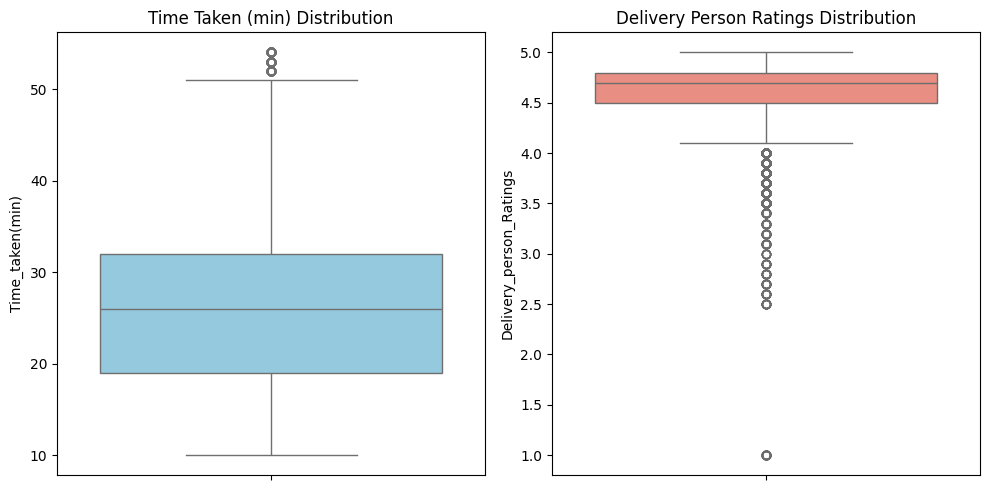

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(y=df['Time_taken(min)'], ax=axes[0], color='skyblue')
axes[0].set_title('Time Taken (min) Distribution')
sns.boxplot(y=df['Delivery_person_Ratings'], ax=axes[1], color='salmon')
axes[1].set_title('Delivery Person Ratings Distribution')

# Step 4: Fix the "Fitting" issue
plt.tight_layout()  # This prevents overlapping between the two plots
plt.savefig('eda_boxplots.png')

create new feature (distance_km) using Haversine formula)

In [ ]:
def calculate_distance(df):
    # Radius of the Earth in kilometers
    R = 6371.0

    # Convert degrees to radians for all coordinate columns
    lat1 = np.radians(df['Restaurant_latitude'])
    lon1 = np.radians(df['Restaurant_longitude'])
    lat2 = np.radians(df['Delivery_location_latitude'])
    lon2 = np.radians(df['Delivery_location_longitude'])

    # Differences in coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# Apply the function to create a new column
df['distance_km'] = calculate_distance(df)

# Show the first few results
print(df[['ID','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude', 'distance_km']].head())

       ID  Restaurant_latitude  Restaurant_longitude  \
0  0x4607            22.745049             75.892471   
1  0xb379            12.913041             77.683237   
2  0x5d6d            12.914264             77.678400   
3  0x7a6a            11.003669             76.976494   
4  0x70a2            12.972793             80.249982   

   Delivery_location_latitude  Delivery_location_longitude  distance_km  
0                   22.765049                    75.912471     3.025149  
1                   13.043041                    77.813237    20.183530  
2                   12.924264                    77.688400     1.552758  
3                   11.053669                    77.026494     7.790401  
4                   13.012793                    80.289982     6.210138  


In [ ]:
print(df['distance_km'].describe())

count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64


In [ ]:
Q1 = df['distance_km'].quantile(0.25)
Q3 = df['distance_km'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['distance_km'] < Q1 - 1.5*IQR) |
              (df['distance_km'] > Q3 + 1.5*IQR)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 0


In [ ]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Time_taken(min),Prep_Time_Min,distance_km
count,41953.0,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000
mean,29.581222,4.633802,18.911397,76.923408,18.975064,76.987074,1.022716,26.311539,9.978865,9.720284
std,5.692692,0.325577,5.467829,3.502910,5.469616,3.503073,0.838893,9.380753,4.008631,5.603083
min,15.0,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,10.000000,5.000000,1.465067
25%,25.0,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,19.000000,5.000000,4.657655
50%,30.0,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,26.000000,10.000000,9.193021
75%,34.0,4.800000,22.751234,78.368855,22.820040,78.405467,2.000000,32.000000,15.000000,13.680920
max,50.0,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,54.000000,15.000000,20.969489


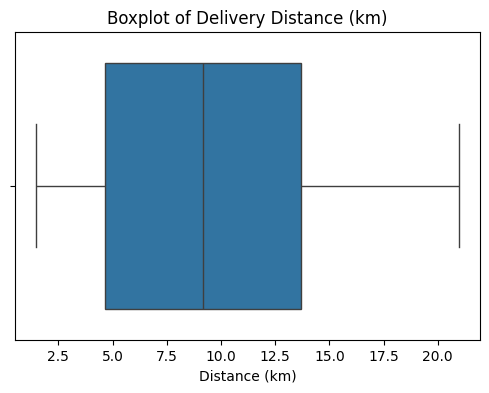

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['distance_km'])
plt.title('Boxplot of Delivery Distance (km)')
plt.xlabel('Distance (km)')
plt.show()

In [ ]:
def calculate_distance(df_test):
    # Radius of the Earth in kilometers
    R = 6371.0

    # Convert degrees to radians for all coordinate columns
    lat1 = np.radians(df_test['Restaurant_latitude'])
    lon1 = np.radians(df_test['Restaurant_longitude'])
    lat2 = np.radians(df_test['Delivery_location_latitude'])
    lon2 = np.radians(df_test['Delivery_location_longitude'])

    # Differences in coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# Apply the function to create a new column
df_test['distance_km'] = calculate_distance(df_test)

# Show the first few results
print(df_test[['ID','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude', 'distance_km']].head())

       ID  Restaurant_latitude  Restaurant_longitude  \
0  0x2318            11.003669             76.976494   
1  0x3474            12.975377             77.696664   
2  0x9420            26.911378             75.789034   
3  0x72ee            26.766536             75.837333   
4  0xa759            12.986047             80.218114   

   Delivery_location_latitude  Delivery_location_longitude  distance_km  
0                   11.043669                    77.016494     6.232373  
1                   13.085377                    77.806664    17.076617  
2                   27.001378                    75.879034    13.406029  
3                   26.856536                    75.927333    13.413644  
4                   13.096047                    80.328114    17.076259  


In [ ]:
Q1 = df_test['distance_km'].quantile(0.25)
Q3 = df_test['distance_km'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_test[(df_test['distance_km'] < Q1 - 1.5*IQR) |
              (df_test['distance_km'] > Q3 + 1.5*IQR)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          41953 non-null  Int64  
 3   Delivery_person_Ratings      41953 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  41953 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

find best performer according to rating_summary

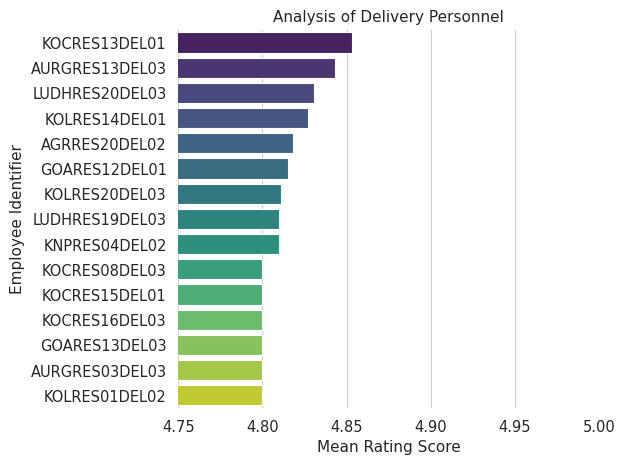

In [ ]:
rating_summary = df.groupby('Delivery_person_ID')['Delivery_person_Ratings'].mean().sort_values(ascending=False)
top_performers = rating_summary.head(15).reset_index()

sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

sns.barplot(
    data=top_performers,
    x='Delivery_person_Ratings',
    y='Delivery_person_ID',
    hue='Delivery_person_ID',
    palette='viridis'
)

plt.title(r'Analysis of Delivery Personnel',size=11)
plt.xlabel('Mean Rating Score', size=11)
plt.ylabel('Employee Identifier', size=11)

# min_val = 4.75
min_val = top_performers['Delivery_person_Ratings'].min()
plt.xlim(min_val - 0.05, 5.0)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('delivery_performance_plot.png', dpi=300)

Rating VS Age

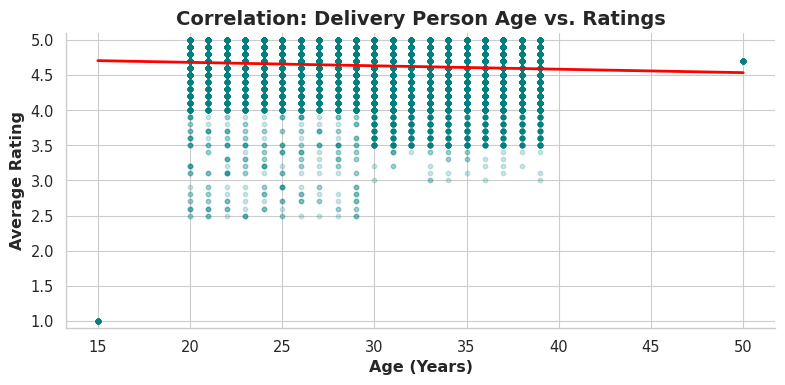

Correlation Coefficient: -0.0854


In [ ]:
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))

# Use regplot to show individual points and the trend line
sns.regplot(
    data=df,
    x='Delivery_person_Age',
    y='Delivery_person_Ratings',
    scatter_kws={'alpha':0.2, 'color':'teal', 's':10}, # 's' is point size
    line_kws={'color':'red', 'lw':2}                  # Red line shows the trend
)

plt.title('Correlation: Delivery Person Age vs. Ratings', weight='bold', size=14)
plt.xlabel('Age (Years)', weight='bold')
plt.ylabel('Average Rating', weight='bold')

plt.ylim(df['Delivery_person_Ratings'].min() - 0.1, 5.1)

sns.despine()
plt.tight_layout()
plt.show()

correlation = df['Delivery_person_Age'].corr(df['Delivery_person_Ratings'])
print(f"Correlation Coefficient: {correlation:.4f}")

Find Peak Delivery Hour for Train Data

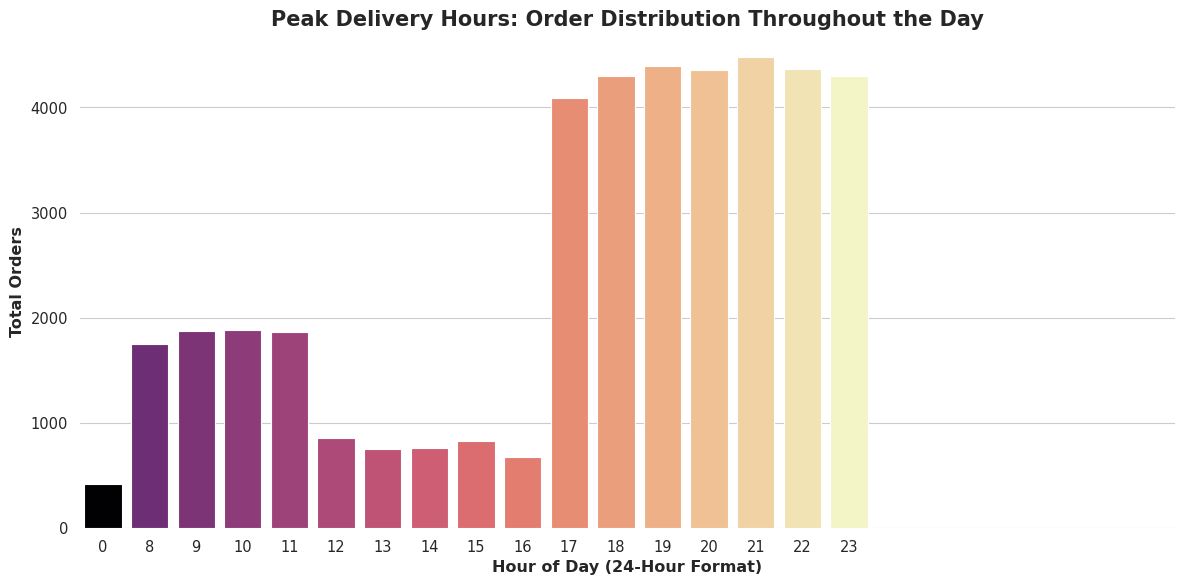

The peak demand occurs at 21:00.


In [ ]:
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")
pd.to_timedelta(df['Time_Orderd'])
plt.figure(figsize=(12, 6))

df['Time_Orderd'] = pd.to_timedelta(df['Time_Orderd'], errors='coerce')
df['Order_Hour'] = df['Time_Orderd'].dt.components.hours
hourly_data = df['Order_Hour'].value_counts().sort_index()

sns.barplot(
    x=hourly_data.index.astype(int),
    y=hourly_data.values,
    hue=hourly_data.index.astype(int),
    palette='magma',
    legend=False
)

plt.title('Peak Delivery Hours: Order Distribution Throughout the Day', weight='bold', size=15)
plt.xlabel('Hour of Day (24-Hour Format)', weight='bold')
plt.ylabel('Total Orders', weight='bold')
plt.xticks(range(0, 24))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

peak_hour = hourly_data.idxmax()
print(f"The peak demand occurs at {int(peak_hour)}:00.")

Find Peak hour for Test Data

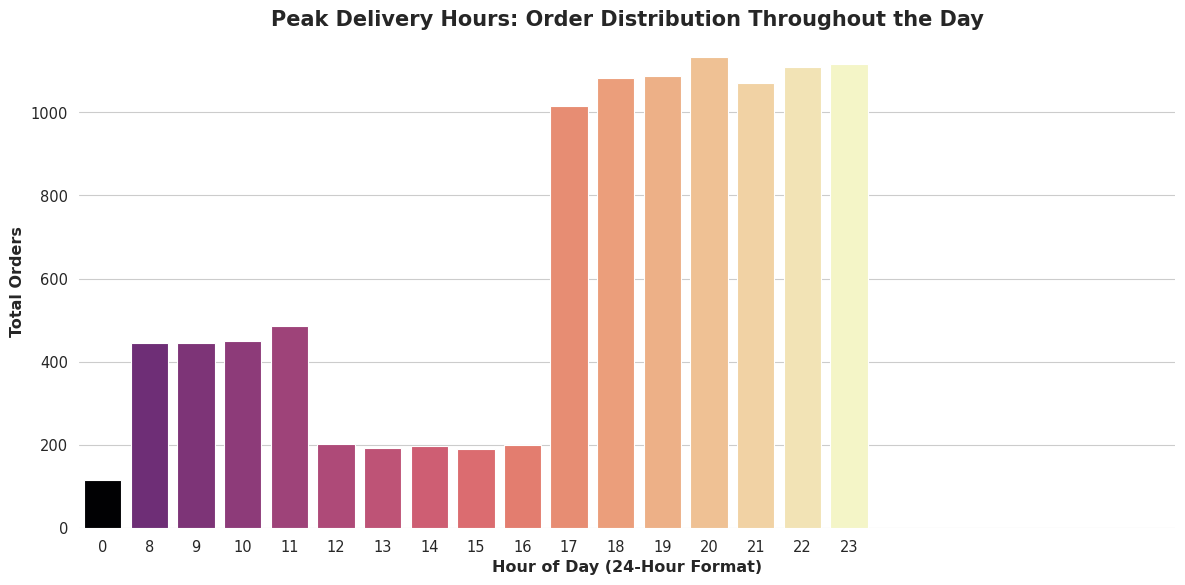

The peak demand occurs at 20:00.


In [ ]:
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")
pd.to_timedelta(df_test['Time_Orderd'])
plt.figure(figsize=(12, 6))

df_test['Time_Orderd'] = pd.to_timedelta(df_test['Time_Orderd'], errors='coerce')
df_test['Order_Hour'] = df_test['Time_Orderd'].dt.components.hours
hourly_data = df_test['Order_Hour'].value_counts().sort_index()

sns.barplot(
    x=hourly_data.index.astype(int),
    y=hourly_data.values,
    hue=hourly_data.index.astype(int),
    palette='magma',
    legend=False
)

plt.title('Peak Delivery Hours: Order Distribution Throughout the Day', weight='bold', size=15)
plt.xlabel('Hour of Day (24-Hour Format)', weight='bold')
plt.ylabel('Total Orders', weight='bold')
plt.xticks(range(0, 24))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

peak_hour = hourly_data.idxmax()
print(f"The peak demand occurs at {int(peak_hour)}:00.")

Order trend in Daily/Weekly

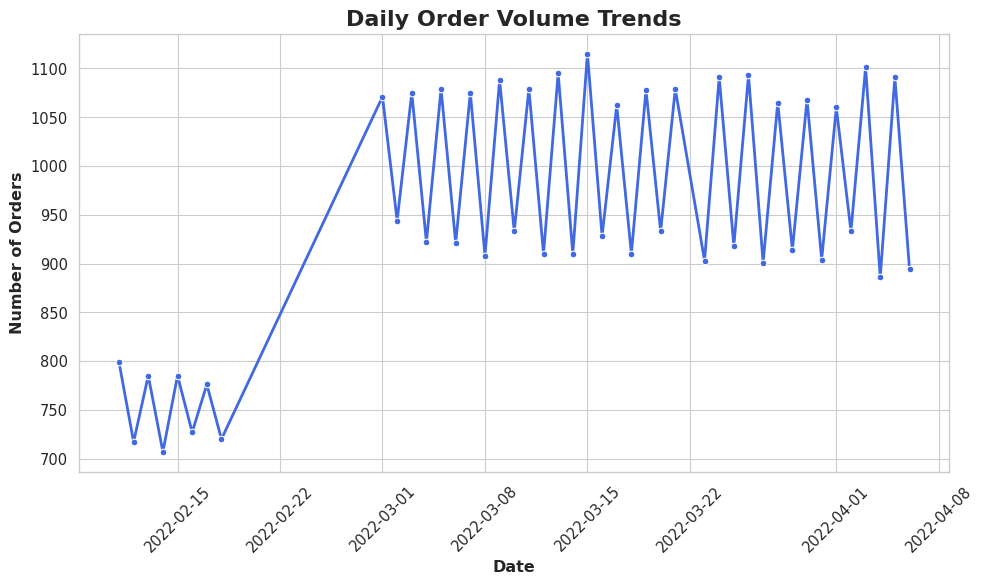

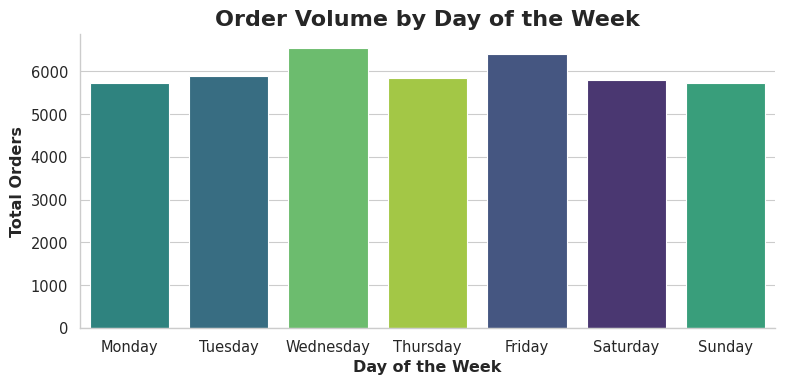

The busiest day of the week is Wednesday.


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
# Order Volume Over Time (Daily)
daily_orders = df.groupby('Order_Date').size().reset_index(name='Order_Count')

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.lineplot(data=daily_orders, x='Order_Date', y='Order_Count', marker='o', color='royalblue', linewidth=2)

plt.title('Daily Order Volume Trends', weight='bold', size=16)
plt.xlabel('Date', weight='bold')
plt.ylabel('Number of Orders', weight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['Day_of_Week'] = df['Order_Date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x='Day_of_Week',
    order=days_order,
    hue='Day_of_Week',
    palette='viridis',
    legend=False
)

plt.title('Order Volume by Day of the Week', weight='bold', size=16)
plt.xlabel('Day of the Week', weight='bold')
plt.ylabel('Total Orders', weight='bold')

sns.despine()
plt.tight_layout()
plt.show()

top_day = df['Day_of_Week'].value_counts().idxmax()
print(f"The busiest day of the week is {top_day}.")

In [ ]:
df_test['Order_Date'] = pd.to_datetime(df_test['Order_Date'], format='%d-%m-%Y')
df_test['Day_of_Week'] = df_test['Order_Date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
top_day_test = df_test['Day_of_Week'].value_counts().idxmax()
print(f"The busiest day of the week is {top_day_test}.")

The busiest day of the week is Wednesday.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   ID                           41953 non-null  object         
 1   Delivery_person_ID           41953 non-null  object         
 2   Delivery_person_Age          41953 non-null  Int64          
 3   Delivery_person_Ratings      41953 non-null  float64        
 4   Restaurant_latitude          41953 non-null  float64        
 5   Restaurant_longitude         41953 non-null  float64        
 6   Delivery_location_latitude   41953 non-null  float64        
 7   Delivery_location_longitude  41953 non-null  float64        
 8   Order_Date                   41953 non-null  datetime64[ns] 
 9   Time_Orderd                  41953 non-null  timedelta64[ns]
 10  Time_Order_picked            41953 non-null  object         
 11  Weatherconditions           

In [106]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   ID                           10529 non-null  object         
 1   Delivery_person_ID           10529 non-null  object         
 2   Delivery_person_Age          10529 non-null  Int64          
 3   Delivery_person_Ratings      10529 non-null  float64        
 4   Restaurant_latitude          10529 non-null  float64        
 5   Restaurant_longitude         10529 non-null  float64        
 6   Delivery_location_latitude   10529 non-null  float64        
 7   Delivery_location_longitude  10529 non-null  float64        
 8   Order_Date                   10529 non-null  datetime64[ns] 
 9   Time_Orderd                  10529 non-null  timedelta64[ns]
 10  Time_Order_picked            10529 non-null  object         
 11  Weatherconditions           

city_code generation from "Delivery_person_ID"

In [ ]:
# df['city_code'] = df['Delivery_person_ID'].str.split('RES').str[0]

# unique_city_codes = sorted(df['city_code'].unique())

# print("Unique City Codes:\n")
# print(unique_city_codes)
# print("\nTotal Unique City Codes:", len(unique_city_codes))

Mapping city_code with city_from_id

In [ ]:
# city_mapping = {
#     'AGR': 'Agra',
#     'ALH': 'Allahabad (Prayagraj)',
#     'AURG': 'Aurangabad',
#     'BANG': 'Bangalore',
#     'BHP': 'Bhopal',
#     'CHEN': 'Chennai',
#     'COIMB': 'Coimbatore',
#     'DEH': 'Dehradun',
#     'GOA': 'Goa',
#     'HYD': 'Hyderabad',
#     'INDO': 'Indore',
#     'JAP': 'Jaipur',
#     'KNP': 'Kanpur',
#     'KOC': 'Kochi',
#     'KOL': 'Kolkata',
#     'LUDH': 'Ludhiana',
#     'MUM': 'Mumbai',
#     'MYS': 'Mysore',
#     'PUNE': 'Pune',
#     'RANCHI': 'Ranchi',
#     'SUR': 'Surat',
#     'VAD': 'Vadodara'
# }
# df['city_from_id'] = df['city_code'].map(city_mapping)

In [ ]:
# df['city_from_id']

In [ ]:
# df = df.drop(columns=['cluster', 'city_code', 'city_from_id'])

In [ ]:
# df.info()

In [ ]:
# from sklearn.cluster import DBSCAN

# coords = df[['Restaurant_latitude', 'Restaurant_longitude']].values

# db = DBSCAN(eps=0.01, min_samples=20).fit(coords)

# df['cluster'] = db.labels_
# city_cluster_counts = df[df['cluster'] != -1]['city_from_id'].value_counts()

# print("High-Density Cities Based on Clustering : ",city_cluster_counts)

# # 2. Create the plot
# plt.figure(figsize=(10, 8))
# sns.barplot(
#     y=city_cluster_counts.index,
#     x=city_cluster_counts.values,
#     hue=city_cluster_counts.values,
#     palette='magma',
#     legend=False
# )
# plt.title('Distribution of High-Density Delivery Points by City', fontsize=16)
# plt.xlabel('Number of Clustered Deliveries', fontsize=12)
# plt.ylabel('City Name', fontsize=12)

# # Add gridlines for easier reading
# plt.grid(axis='x', linestyle='--', alpha=0.7)

# # Add data labels at the end of each bar
# for i, v in enumerate(city_cluster_counts.values):
#     plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

# plt.tight_layout()
# plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   ID                           41953 non-null  object         
 1   Delivery_person_ID           41953 non-null  object         
 2   Delivery_person_Age          41953 non-null  Int64          
 3   Delivery_person_Ratings      41953 non-null  float64        
 4   Restaurant_latitude          41953 non-null  float64        
 5   Restaurant_longitude         41953 non-null  float64        
 6   Delivery_location_latitude   41953 non-null  float64        
 7   Delivery_location_longitude  41953 non-null  float64        
 8   Order_Date                   41953 non-null  datetime64[ns] 
 9   Time_Orderd                  41953 non-null  timedelta64[ns]
 10  Time_Order_picked            41953 non-null  object         
 11  Weatherconditions           

order_type across city

The city with the highest total orders is: Metropolitian

--- Top City for each Order Type ---
Type_of_order
Buffet    Metropolitian
Drinks    Metropolitian
Meal      Metropolitian
Snack     Metropolitian
Name: City, dtype: object


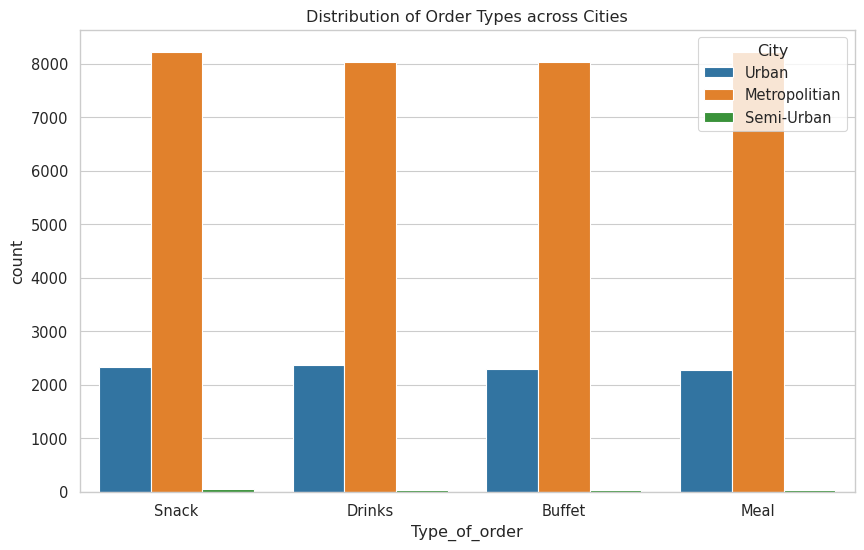

In [107]:
# 2. Basic Cleaning (Stripping whitespaces as the raw data has trailing spaces)
df['City'] = df['City'].str.strip()
df['Type_of_order'] = df['Type_of_order'].str.strip()

# 3. Find which City has the most orders overall
top_city_overall = df['City'].value_counts().idxmax()
print(f"The city with the highest total orders is: {top_city_overall}")

# 4. Find the most popular City FOR EACH Type of Order
# We group by Type_of_order and then find the City with the highest count in each group
top_cities_by_order = df.groupby('Type_of_order')['City'].agg(lambda x: x.value_counts().idxmax())

print("\n--- Top City for each Order Type ---")
print(top_cities_by_order)

# 5. Visualizing the distribution (Optional but helpful)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Type_of_order', hue='City')
plt.title('Distribution of Order Types across Cities')
plt.show()

Average time_taken(min) by WeatherConditions

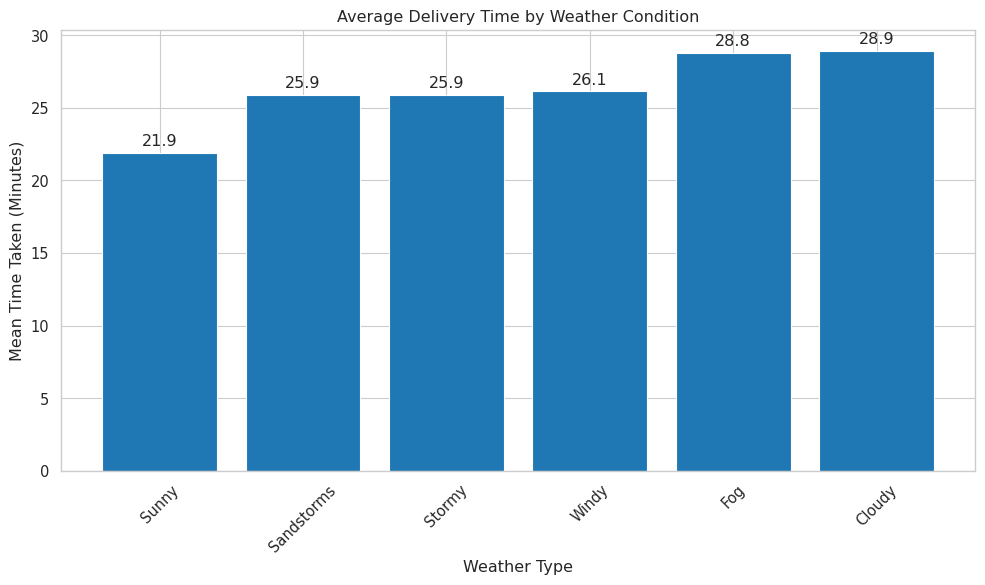

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean Time column
df['Time_taken(min)'] = pd.to_numeric(
    df['Time_taken(min)'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

# 2. Clean Weather column (remove spaces if needed)
df['Weatherconditions'] = df['Weatherconditions'].astype(str).str.strip()

# 3. Group by weather and calculate mean
weather_avg = df.groupby('Weatherconditions')['Time_taken(min)'].mean().sort_values()

# 4. Plot
plt.figure(figsize=(10,6))
bars = plt.bar(weather_avg.index, weather_avg.values)

plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather Type")
plt.ylabel("Mean Time Taken (Minutes)")
plt.xticks(rotation=45)

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             f'{yval:.1f}',
             ha='center')

plt.tight_layout()
plt.show()


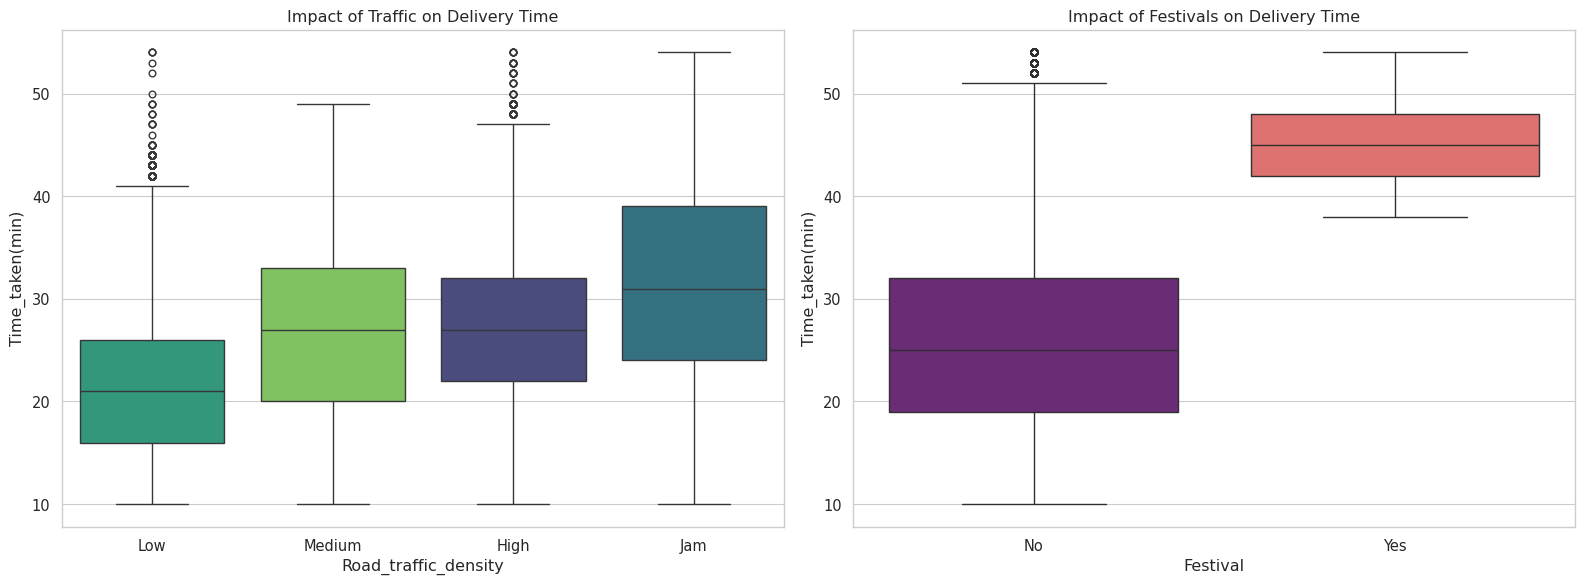

In [109]:
for col in ['Road_traffic_density', 'Festival']:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace('NaN', None)

plot_df = df.dropna(subset=['Road_traffic_density', 'Festival'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], x='Road_traffic_density', y='Time_taken(min)',
            data=plot_df,hue='Road_traffic_density', palette='viridis', order=['Low', 'Medium', 'High', 'Jam'])
axes[0].set_title('Impact of Traffic on Delivery Time')

sns.boxplot(ax=axes[1], x='Festival', y='Time_taken(min)', hue='Festival',
            data=plot_df, palette='magma')
axes[1].set_title('Impact of Festivals on Delivery Time')

plt.tight_layout()
plt.show()

Count of Order Types by Festival Status:
Festival          No  Yes
Type_of_order            
Buffet         10173  195
Drinks         10242  203
Meal           10325  199
Snack          10391  225


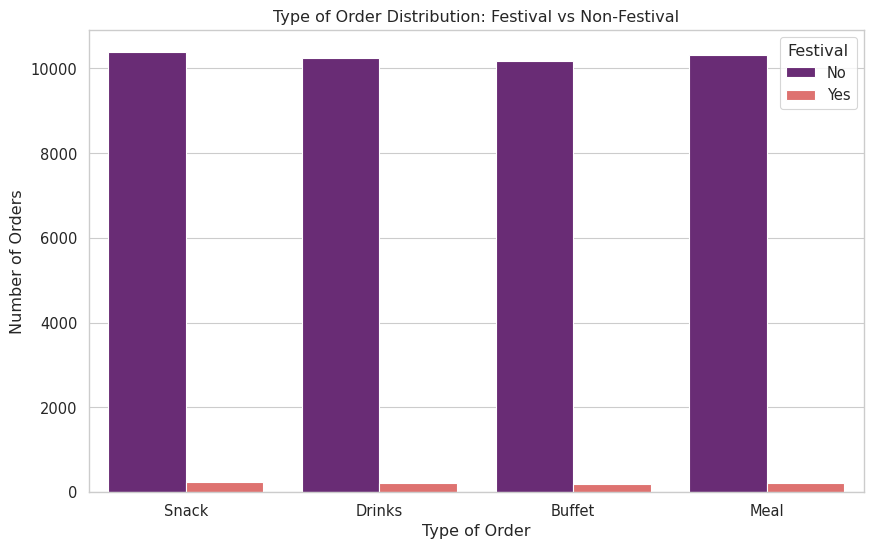

In [110]:
df['Festival'] = df['Festival'].str.strip()
df['Type_of_order'] = df['Type_of_order'].str.strip()

order_fest_table = pd.crosstab(df['Type_of_order'], df['Festival'])
print("Count of Order Types by Festival Status:")
print(order_fest_table)

order_fest_pct = pd.crosstab(df['Type_of_order'], df['Festival'], normalize='columns') * 100


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Type_of_order', hue='Festival', palette='magma')

plt.title('Type of Order Distribution: Festival vs Non-Festival')
plt.xlabel('Type of Order')
plt.ylabel('Number of Orders')
plt.legend(title='Festival')
plt.show()

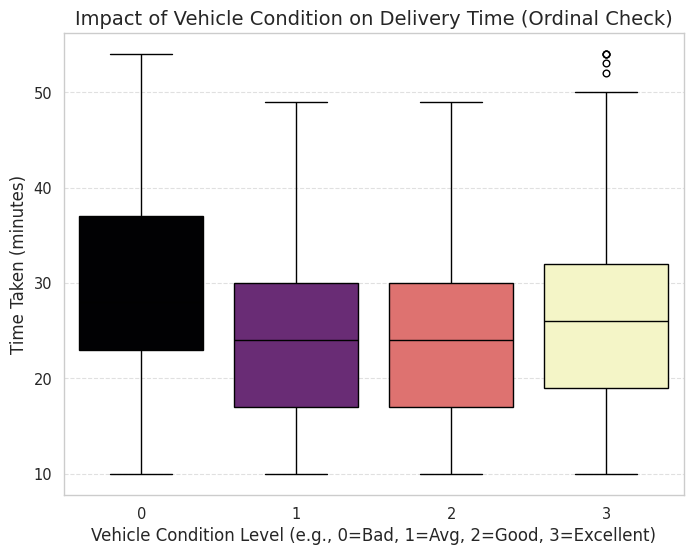

In [111]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Vehicle_condition',
    y='Time_taken(min)',
    data=df,
    hue='Vehicle_condition',
    palette='magma',
    legend=False
)

# Adding labels and title
plt.title('Impact of Vehicle Condition on Delivery Time (Ordinal Check)', fontsize=14)
plt.xlabel('Vehicle Condition Level (e.g., 0=Bad, 1=Avg, 2=Good, 3=Excellent)', fontsize=12)
plt.ylabel('Time Taken (minutes)', fontsize=12)

# Optional: Add a grid to make comparing median lines easier
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

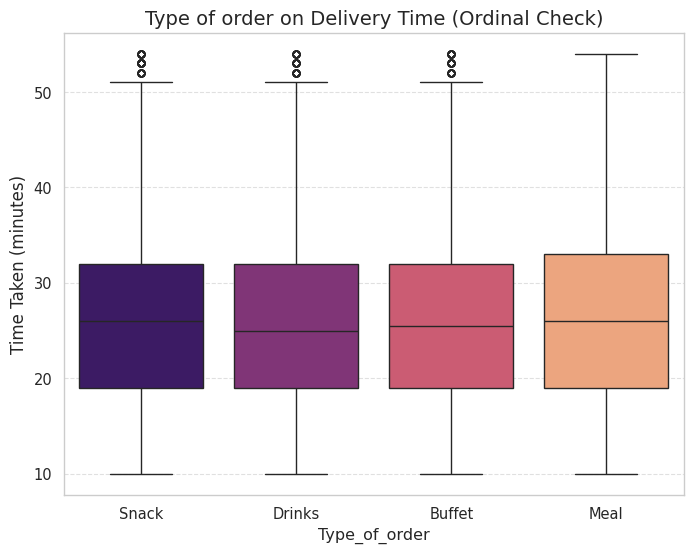

In [112]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Type_of_order',
    y='Time_taken(min)',
    data=df,
    hue='Type_of_order',
    palette='magma',
    legend=False
)

# Adding labels and title
plt.title('Type of order on Delivery Time (Ordinal Check)', fontsize=14)
# plt.xlabel('Vehicle Condition Level (e.g., 0=Bad, 1=Avg, 2=Good, 3=Excellent)', fontsize=12)
plt.ylabel('Time Taken (minutes)', fontsize=12)

# Optional: Add a grid to make comparing median lines easier
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

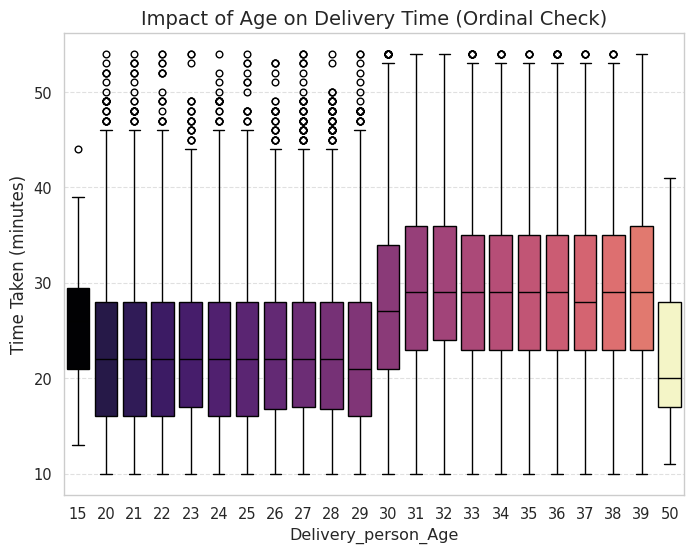

In [113]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Delivery_person_Age',
    y='Time_taken(min)',
    data=df,
    hue='Delivery_person_Age',
    palette='magma',
    legend=False
)

# Adding labels and title
plt.title('Impact of Age on Delivery Time (Ordinal Check)', fontsize=14)
# plt.xlabel('Vehicle Condition Level (e.g., 0=Bad, 1=Avg, 2=Good, 3=Excellent)', fontsize=12)
plt.ylabel('Time Taken (minutes)', fontsize=12)

# Optional: Add a grid to make comparing median lines easier
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Top-10 high density Restaurants according to latitude, longitude

Fetching real city names... (Please wait)


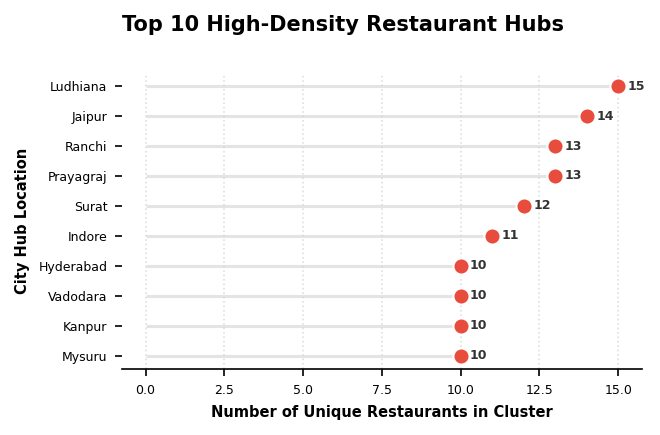

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

mask = (df['Restaurant_latitude'] != 0) & (df['Restaurant_longitude'] != 0)
df_clean = df[mask].copy()

df_geo_unique = df_clean[['Restaurant_latitude', 'Restaurant_longitude']].drop_duplicates().copy()

db = DBSCAN(eps=0.015, min_samples=5).fit(df_geo_unique.values)
df_geo_unique['Cluster_ID'] = db.labels_

clusters = df_geo_unique[df_geo_unique['Cluster_ID'] != -1]
cluster_centers = clusters.groupby('Cluster_ID').agg({
    'Restaurant_latitude': 'mean',
    'Restaurant_longitude': 'mean',
    'Cluster_ID': 'size'
}).rename(columns={'Cluster_ID': 'Restaurant_Count'}).reset_index()


geolocator = Nominatim(user_agent="food_delivery_hotspots_v3")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_city_name(row):
    try:
        location = reverse((row['Restaurant_latitude'], row['Restaurant_longitude']), language='en')
        if location:
            address = location.raw.get('address', {})
            return address.get('city', address.get('town', address.get('village', 'Unknown Area')))
        return "Not Found"
    except:
        return "Service Timeout"

print("Fetching real city names... (Please wait)")
cluster_centers['City_Name'] = cluster_centers.apply(get_city_name, axis=1)

top_10 = cluster_centers.sort_values(by='Restaurant_Count', ascending=True).tail(10)

plt.style.use('default')
plt.figure(figsize=(4.5, 3), dpi=150)

plt.hlines(y=top_10['City_Name'], xmin=0, xmax=top_10['Restaurant_Count'],
           color='#D3D3D3', alpha=0.6, linewidth=1.5)

plt.scatter(top_10['Restaurant_Count'], top_10['City_Name'],
            color='#E74C3C', s=60, alpha=1, edgecolors='white', zorder=3)

plt.yticks(fontsize=6)
plt.xticks(fontsize=6)

plt.title('Top 10 High-Density Restaurant Hubs', fontsize=10, fontweight='semibold', loc='left', pad=20)
plt.xlabel('Number of Unique Restaurants in Cluster', fontsize=7, fontweight='semibold')
plt.ylabel('City Hub Location', fontsize=7, fontweight='semibold')
plt.grid(axis='x', linestyle=':', alpha=0.4)

for i, row in top_10.iterrows():
    plt.text(row['Restaurant_Count'] + 0.3, row['City_Name'], f"{int(row['Restaurant_Count'])}",
             va='center', fontsize=6, fontweight='bold', color='#333333')

sns.despine(top=True, right=True, left=True)

plt.tight_layout()
plt.show()

In [115]:
print(df.skew(numeric_only=True))

Delivery_person_Age            0.008104
Delivery_person_Ratings         -2.7024
Restaurant_latitude            0.107042
Restaurant_longitude           1.192992
Delivery_location_latitude     0.107758
Delivery_location_longitude    1.192173
Vehicle_condition              0.073753
Time_taken(min)                0.481881
Prep_Time_Min                  0.007861
distance_km                    0.324622
Order_Hour                    -1.025474
dtype: Float64


Compare distribution for Train Data and Test Data

In [116]:
stats_comparison = pd.DataFrame({
    'Train_Mean': df.mean(numeric_only=True),
    'Test_Mean': df_test.mean(numeric_only=True),
    'Train_Std': df.std(numeric_only=True),
    'Test_Std': df_test.std(numeric_only=True)
})

stats_comparison['Mean_Diff_%'] = abs((stats_comparison['Train_Mean'] - stats_comparison['Test_Mean']) / stats_comparison['Train_Mean']) * 100
print(stats_comparison)

                             Train_Mean  Test_Mean  Train_Std  Test_Std  \
Delivery_location_latitude    18.975064  19.016163   5.469616  5.483759   
Delivery_location_longitude   76.987074  76.972202   3.503073   3.48002   
Delivery_person_Age           29.581222  29.533289   5.692692   5.66612   
Delivery_person_Ratings        4.633802   4.634533   0.325577  0.334597   
Order_Hour                    17.418897  17.443157   4.820644  4.839112   
Prep_Time_Min                  9.978865    10.0586   4.008631  4.006141   
Restaurant_latitude           18.911397  18.952246   5.467829  5.482584   
Restaurant_longitude          76.923408  76.908285    3.50291   3.47933   
Time_taken(min)               26.311539       <NA>   9.380753      <NA>   
Vehicle_condition              1.022716   1.026403   0.838893  0.838761   
distance_km                    9.720284   9.758698   5.603083   5.60852   

                             Mean_Diff_%  
Delivery_location_latitude      0.216596  
Delivery_loca

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   ID                           41953 non-null  object         
 1   Delivery_person_ID           41953 non-null  object         
 2   Delivery_person_Age          41953 non-null  Int64          
 3   Delivery_person_Ratings      41953 non-null  float64        
 4   Restaurant_latitude          41953 non-null  float64        
 5   Restaurant_longitude         41953 non-null  float64        
 6   Delivery_location_latitude   41953 non-null  float64        
 7   Delivery_location_longitude  41953 non-null  float64        
 8   Order_Date                   41953 non-null  datetime64[ns] 
 9   Time_Orderd                  41953 non-null  timedelta64[ns]
 10  Time_Order_picked            41953 non-null  object         
 11  Weatherconditions           

In [118]:
print(df[['Road_traffic_density', 'Festival','Weatherconditions','City','Type_of_vehicle','Type_of_order']].isna().sum())
print(df[['Road_traffic_density','Weatherconditions','City','Type_of_vehicle','Type_of_order']].nunique())

Road_traffic_density    0
Festival                0
Weatherconditions       0
City                    0
Type_of_vehicle         0
Type_of_order           0
dtype: int64
Road_traffic_density    4
Weatherconditions       6
City                    3
Type_of_vehicle         4
Type_of_order           4
dtype: int64


In [119]:
print(df_test[['Road_traffic_density', 'Festival','Weatherconditions','City','Type_of_vehicle','Type_of_order']].isna().sum())
print(df_test[['Road_traffic_density','Weatherconditions','City','Type_of_vehicle','Type_of_order']].nunique())

Road_traffic_density    0
Festival                0
Weatherconditions       0
City                    0
Type_of_vehicle         0
Type_of_order           0
dtype: int64
Road_traffic_density    4
Weatherconditions       6
City                    3
Type_of_vehicle         4
Type_of_order           4
dtype: int64


In [120]:
df_label = df.copy()
df_test_label = df_test.copy()

In [121]:
df_test_label.shape

(10529, 23)

In [122]:
df_test.shape

(10529, 23)

Data Transformation for Categorical Data (Test, Train)

In [123]:
# Ordinal Encoding for Traffic
traffic_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
df['Road_traffic_density'] = df['Road_traffic_density'].map(traffic_mapping)
df_test['Road_traffic_density'] = df_test['Road_traffic_density'].map(traffic_mapping)

# Binary Encoding for Festival
df['Festival'] = df['Festival'].map({'Yes': 1, 'No': 0})
df_test['Festival'] = df_test['Festival'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for others (Weather, City, Vehicle)
# Notice 'Type_of_order' is NOT in this list
df = pd.get_dummies(df, columns=['Weatherconditions', 'City', 'Type_of_vehicle','Type_of_order','Day_of_Week'], drop_first=False)
df_test = pd.get_dummies(df_test, columns=['Weatherconditions', 'City', 'Type_of_vehicle','Type_of_order','Day_of_Week'], drop_first=False)


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype          
---  ------                            --------------  -----          
 0   ID                                41953 non-null  object         
 1   Delivery_person_ID                41953 non-null  object         
 2   Delivery_person_Age               41953 non-null  Int64          
 3   Delivery_person_Ratings           41953 non-null  float64        
 4   Restaurant_latitude               41953 non-null  float64        
 5   Restaurant_longitude              41953 non-null  float64        
 6   Delivery_location_latitude        41953 non-null  float64        
 7   Delivery_location_longitude       41953 non-null  float64        
 8   Order_Date                        41953 non-null  datetime64[ns] 
 9   Time_Orderd                       41953 non-null  timedelta64[ns]
 10  Time_Order_picked                 

In [125]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype          
---  ------                            --------------  -----          
 0   ID                                10529 non-null  object         
 1   Delivery_person_ID                10529 non-null  object         
 2   Delivery_person_Age               10529 non-null  Int64          
 3   Delivery_person_Ratings           10529 non-null  float64        
 4   Restaurant_latitude               10529 non-null  float64        
 5   Restaurant_longitude              10529 non-null  float64        
 6   Delivery_location_latitude        10529 non-null  float64        
 7   Delivery_location_longitude       10529 non-null  float64        
 8   Order_Date                        10529 non-null  datetime64[ns] 
 9   Time_Orderd                       10529 non-null  timedelta64[ns]
 10  Time_Order_picked                 

In [126]:
df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)
df_test['multiple_deliveries'] = df_test['multiple_deliveries'].astype(int)

In [127]:
# Select only the columns created by OHE (bool/uint8 types)
ohe_cols = df.select_dtypes(include=['bool', 'uint8'])

# Calculate number of zeros
zero_count = (ohe_cols == 0).sum().sum()

# Total number of elements in the OHE section
total_elements = ohe_cols.size

# Sparsity formula
sparsity = (zero_count / total_elements) * 100

print(f"Sparsity of OHE features: {sparsity:.2f}%")
print(f"Density of OHE features: {100 - sparsity:.2f}%")

Sparsity of OHE features: 79.17%
Density of OHE features: 20.83%


In [ ]:
# Select only the columns created by OHE (bool/uint8 types)
ohe_cols = df_test.select_dtypes(include=['bool', 'uint8'])

# Calculate number of zeros
zero_count = (ohe_cols == 0).sum().sum()

# Total number of elements in the OHE section
total_elements = ohe_cols.size

# Sparsity formula
sparsity = (zero_count / total_elements) * 100

print(f"Sparsity of OHE features: {sparsity:.2f}%")
print(f"Density of OHE features: {100 - sparsity:.2f}%")

Sparsity of OHE features: 79.17%
Density of OHE features: 20.83%


In [129]:
from google.colab import files
df_test.to_csv('test_cleaned.csv', index=False)
files.download('test_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [130]:
# from google.colab import files
df_test.to_csv('train_cleaned.csv', index=False)
files.download('train_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data Normalization

In [ ]:
# from sklearn.preprocessing import StandardScaler
# df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce')
# df_test['multiple_deliveries'] = pd.to_numeric(df_test['multiple_deliveries'], errors='coerce')

# features_to_normalize = [
#     'Delivery_person_Age',
#     'Delivery_person_Ratings',
#     'Vehicle_condition',
#     'Prep_Time_Min',
#     'distance_km',
#     'Order_Hour',
#     'multiple_deliveries'
# ]
# std_scaler = StandardScaler()
# df[features_to_normalize] = std_scaler.fit_transform(df[features_to_normalize])
# df_test[features_to_normalize] = std_scaler.fit_transform(df_test[features_to_normalize])

# print(df[features_to_normalize].head())
# print(df_test[features_to_normalize].head())

Spearman Correlation

--- Spearman Correlation with Delivery Time ---
Time_taken(min)                1.000000
Road_traffic_density           0.415260
distance_km                    0.319452
Delivery_person_Age            0.309001
Festival                       0.223836
Order_Hour                     0.101646
Time_Orderd                    0.100863
Delivery_location_latitude     0.029359
Delivery_location_longitude    0.026964
Restaurant_latitude            0.011504
Restaurant_longitude           0.004959
Prep_Time_Min                 -0.007346
Vehicle_condition             -0.222535
Delivery_person_Ratings       -0.287274
Name: Time_taken(min), dtype: float64


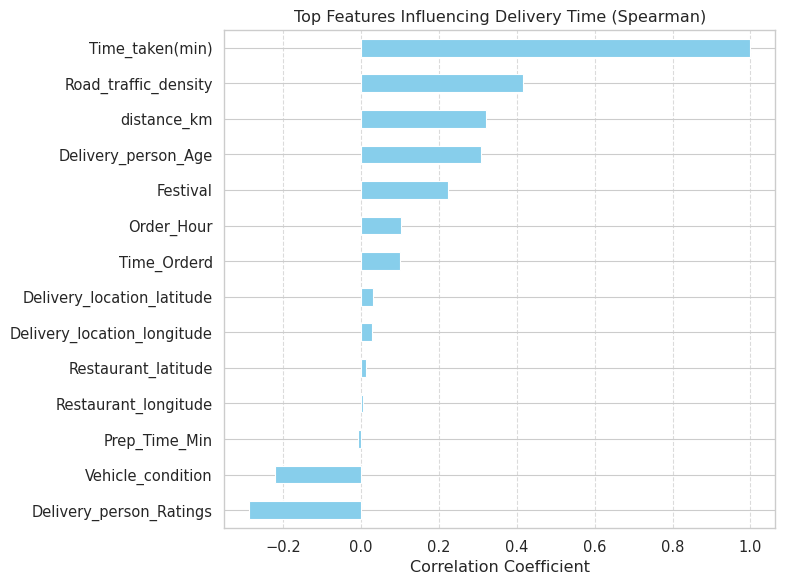

In [ ]:
df_numeric_only = df.select_dtypes(include=['number'])
spearman_matrix = df_numeric_only.corr(method='spearman')
time_correlation = spearman_matrix['Time_taken(min)'].sort_values(ascending=False)
print("--- Spearman Correlation with Delivery Time ---")
print(time_correlation)
top_features = time_correlation.head(15)
# 3. Visualizing the Top Correlations
# To avoid a messy heatmap with too many One-Hot columns,
# we plot only the top 15 most influential features.
plt.figure(figsize=(8, 6))
top_features.plot(kind='barh', color='skyblue')
plt.title('Top Features Influencing Delivery Time (Spearman)')
plt.xlabel('Correlation Coefficient')
plt.gca().invert_yaxis()  # Ensures the highest correlation is at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,10))

# # corr() function with numeric features
# cor = df.corr(numeric_only=True)

# # heap map with target variable(Time_taken)
# sns.heatmap(cor[['Time_taken(min)']].sort_values(by='Time_taken(min)', ascending=False),
#             annot=True,
#             cmap='coolwarm')

# plt.show()

Lasso Regression(Base-line model)


--- Lasso Performance ---
R^2 Score: 0.5150
MAE: 5.14 minutes


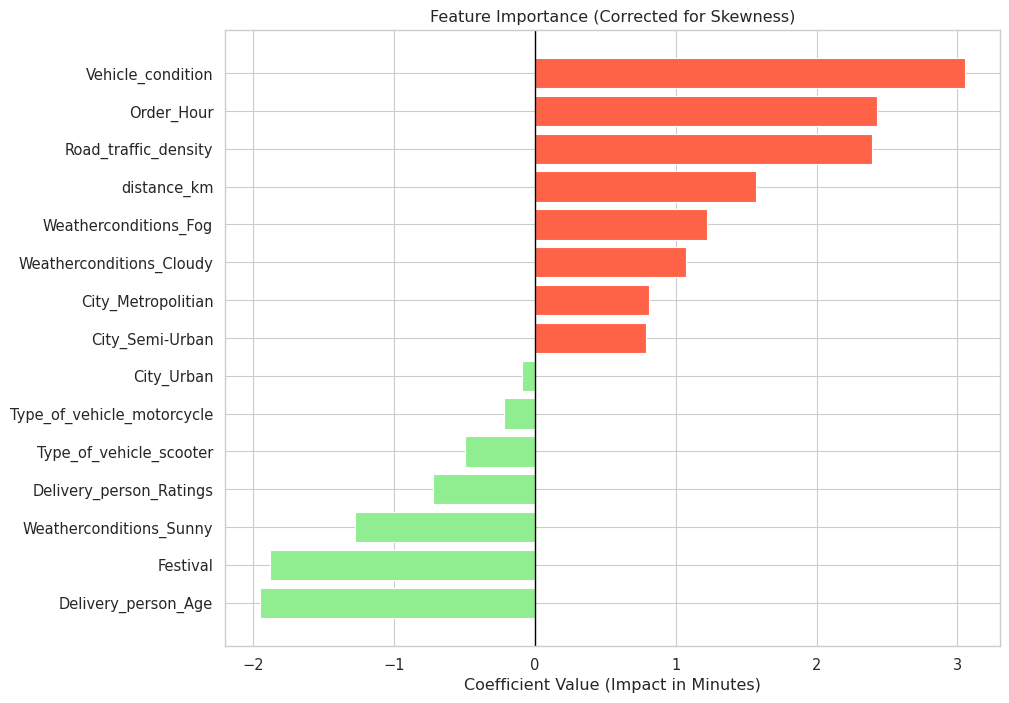

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer

def prepare_features(data):
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

temp_numeric = prepare_features(df)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()

threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()

if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df)[relevant_features]
y_all = df['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
X_test_final = prepare_features(df_test).reindex(columns=X_train.columns, fill_value=0)

alphas = np.logspace(-4, 1, 100)
skewed_cols = ['Delivery_person_Ratings', 'Order_Hour']
preprocessor = ColumnTransformer(
    transformers=[
        ('unskew', PowerTransformer(method='yeo-johnson'), skewed_cols)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=alphas, cv=5, max_iter=10000)) # Automatically picks the best alpha
    ])

pipeline.fit(X_train, y_train)

y_val_pred = pipeline.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f"\n--- Lasso Performance ---")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} minutes")

coefficients = pipeline.named_steps['lasso'].coef_
importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': coefficients
}).sort_values(by='Importance')

plt.figure(figsize=(10, 8))
colors = ['tomato' if c > 0 else 'lightgreen' for c in importance_df['Importance']]
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.axvline(0, color='black', lw=1)
plt.xlabel('Coefficient Value (Impact in Minutes)')
plt.title('Feature Importance (Corrected for Skewness)')
plt.show()

check for overfitting

In [ ]:
y_train_pred = pipeline.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

print(f"--- Overfitting Check ---")
print(f"Train R^2: {r2_train:.4f} | Val R^2: {r2:.4f}")
print(f"Train MAE: {mae_train:.2f} | Val MAE: {mae:.2f}")

r2_gap = r2_train - r2
print(f"R^2 Gap: {r2_gap:.4f}")

if r2_gap > 0.1:
    print("Potential Overfitting (Gap is large)")
else:
    print("Model is Generalizing Well (Small gap)")

--- Overfitting Check ---
Train R^2: 0.5316 | Val R^2: 0.5150
Train MAE: 5.14 | Val MAE: 5.14
R^2 Gap: 0.0166
Model is Generalizing Well (Small gap)


Saving model and load/use model

In [ ]:
import joblib

# Define the filename
model_filename = 'food_delivery_lasso_model.pkl'

# Save the entire pipeline
joblib.dump(pipeline, model_filename)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as food_delivery_lasso_model.pkl


In [ ]:
# Load the saved model
loaded_model = joblib.load('food_delivery_lasso_model.pkl')

# Use it to predict on new data
# Note: X_test_final must have the same features as your training data
new_predictions = loaded_model.predict(X_test_final)

print("Predictions from loaded model complete.")
print(new_predictions[:10])

Predictions from loaded model complete.
[16.59114349 36.03779701 33.6618805  26.73948464 25.1729518  24.56745169
 11.27828242 26.97692103 30.0663018  23.13756181]


Based-line model (Linear Regression)

In [ ]:
# from sklearn.model_selection import train_test_split

# baseline_features = [
#     'Road_traffic_density',   # 0.41
#     'multiple_deliveries',     # 0.38
#     'Delivery_person_Ratings',# -0.33
#     'distance_km',            # 0.32
#     'Delivery_person_Age',    # 0.29
#     'Festival',               # 0.29
#     'Vehicle_condition',      # -0.24
#     'Weatherconditions_Sunny',# -0.21
#     'City_Urban',             # -0.19
#     'Order_Hour',             # 0.18
#     'Type_of_vehicle_motorcycle', # 0.16
#     'City_Semi-Urban',        # 0.15
#     'Type_of_vehicle_scooter',# -0.14
#     'Weatherconditions_Fog'   # 0.12
# ]

# # 2. Define X and y
# X = df[baseline_features]
# y = df['Time_taken(min)']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42, stratify=X['Festival']
# )

# print(f"Splitting Complete (8:2):")
# print(f"Training set: {len(X_train)} rows (80%)")
# print(f"Testing set: {len(X_test)} rows (20%)")


In [ ]:
# # Function to get target statistics
# def get_stats(y_data, name):
#     return {
#         'Set': name,
#         'Mean Time': y_data.mean(),
#         'Std Dev': y_data.std(),
#         'Min': y_data.min(),
#         'Max': y_data.max()
#     }

# # Create a DataFrame for target statistics
# stats_df = pd.DataFrame([
#     get_stats(y, 'Full Dataset'),
#     get_stats(y_train, 'Train (80%)'),
#     get_stats(y_test, 'Test (20%)')
# ])

# # Calculate Festival balance (Percentages)
# fest_balance = pd.DataFrame({
#     'Train (%)': X_train['Festival'].value_counts(normalize=True) * 100,
#     'Test (%)': X_test['Festival'].value_counts(normalize=True) * 100
# })

# print("\n--- Target Variable [Time_taken(min)] Statistics ---")
# print(stats_df)

# print("\n--- Festival Feature Balance ---")
# print(fest_balance)

In [ ]:
# from sklearn.model_selection import cross_val_score, cross_val_predict
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# model = LinearRegression()

# # scoring='r2' means R-squared for each fold
# cv_r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

# # scoring='neg_mean_absolute_error' returns negative values, so we take the absolute
# cv_mae_scores = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

# print(f"--- 5-Fold Cross-Validation Results ---")
# print(f"R2 Scores per Fold: {cv_r2_scores}")
# print(f"Average R2: {cv_r2_scores.mean():.4f}")
# print(f"Average MAE: {cv_mae_scores.mean():.2f} minutes")
# print(f"Stability (Std Dev of R2): {cv_r2_scores.std():.4f}\n")

# model.fit(X_train, y_train)
# test_preds = model.predict(X_test)

# print(f"Final Test Set Results (20% Hold-out)")
# print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.2f} minutes")
# print(f"Test R2 Score: {r2_score(y_test, test_preds):.4f}")

check overfit or not in linear Regression


In [ ]:
# train_preds = model.predict(X_train)
# test_preds = model.predict(X_test)

# mae_train = mean_absolute_error(y_train, train_preds)
# r2_train = r2_score(y_train, train_preds)

# mae_test = mean_absolute_error(y_test, test_preds)
# r2_test = r2_score(y_test, test_preds)

# print(f"Overfitting Check: Training vs. Testing")
# print(f"Train MAE: {mae_train:.2f} mins | Test MAE: {mae_test:.2f} mins")
# print(f"Train R2:  {r2_train:.4f}     | Test R2:  {r2_test:.4f}")

In [ ]:
# print(df.loc[19669])

Random Forest(OHE)


--- Random Forest Performance ---
R^2 Score: 0.7895
MAE: 3.38 minutes


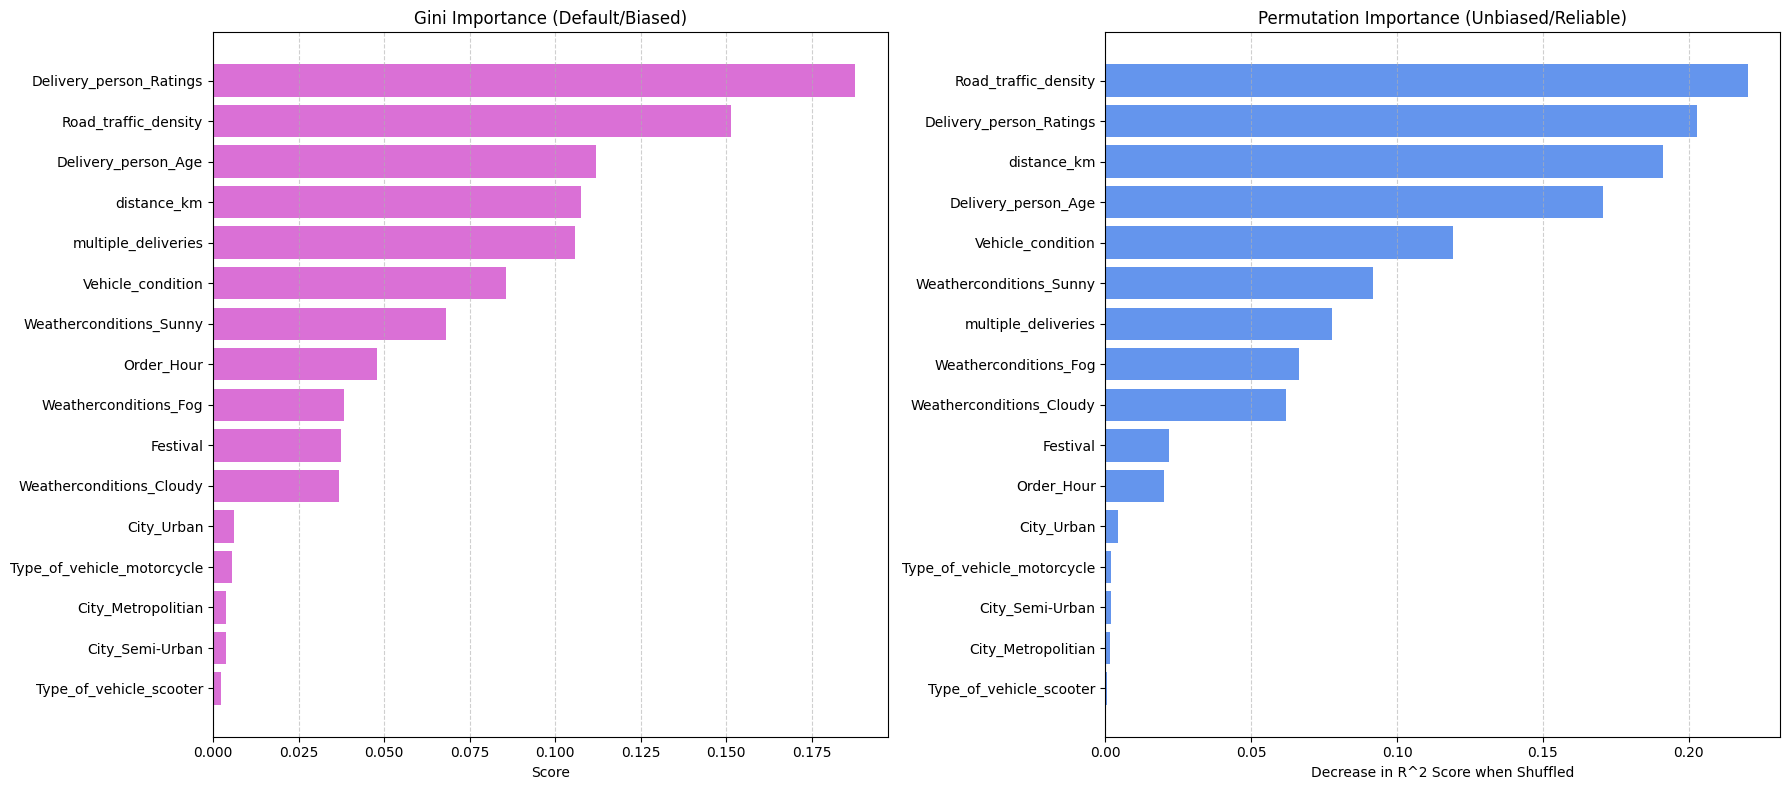

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

def prepare_features(data):
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

temp_numeric = prepare_features(df)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()

threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()
if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df)[relevant_features]
y_all = df['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

rf_pipeline = Pipeline([
    ('rf', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_val_pred = rf_pipeline.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f"\n--- Random Forest Performance ---")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} minutes")

result = permutation_importance(
    rf_pipeline, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

importances = rf_pipeline.named_steps['rf'].feature_importances_
gini_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Gini Importance Plot
ax1.barh(gini_importance_df['Feature'], gini_importance_df['Importance'], color='orchid')
ax1.set_title('Gini Importance (Default/Biased)')
ax1.set_xlabel('Score')
ax1.grid(axis='x', linestyle='--', alpha=0.6)

# Permutation Importance Plot
ax2.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], color='cornflowerblue')
ax2.set_title('Permutation Importance (Unbiased/Reliable)')
ax2.set_xlabel('Decrease in R^2 Score when Shuffled')
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
y_train_pred = rf_pipeline.predict(X_train)
y_val_pred = rf_pipeline.predict(X_val)

r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"--- Overfitting Check: Random Forest ---")
print(f"{'Metric':<10} | {'Train Set':<10} | {'Validation Set':<15}")
print("-" * 45)
print(f"{'R2 Score':<10} | {r2_train:<10.4f} | {r2_val:<15.4f}")
print(f"{'MAE':<10} | {mae_train:<10.2f} | {mae_val:<15.2f}")

gap = r2_train - r2_val
if gap > 0.15:
    print(f"\nSTATUS: Significant Overfitting detected (Gap: {gap:.4f}).")
    print("Action: Consider decreasing 'max_depth' or increasing 'min_samples_leaf'.")
else:
    print(f"\nGood Generalization (Gap: {gap:.4f}).")

--- Overfitting Check: Random Forest ---
Metric     | Train Set  | Validation Set 
---------------------------------------------
R2 Score   | 0.7841     | 0.7666         
MAE        | 3.47       | 3.56           

Good Generalization (Gap: 0.0175).


In [135]:
import joblib
from sklearn.pipeline import Pipeline

# Define the filename
model_filename = 'food_delivery_rf_model.pkl'

# Save the entire pipeline
joblib.dump(rf_pipeline, model_filename)

print(f"Model saved successfully as {model_filename}")


Model saved successfully as food_delivery_rf_model.pkl


In [136]:
files.download('food_delivery_rf_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

XGBoost with OHE


--- XGBoost Performance ---
R^2 Score: 0.8101
MAE: 3.21 minutes


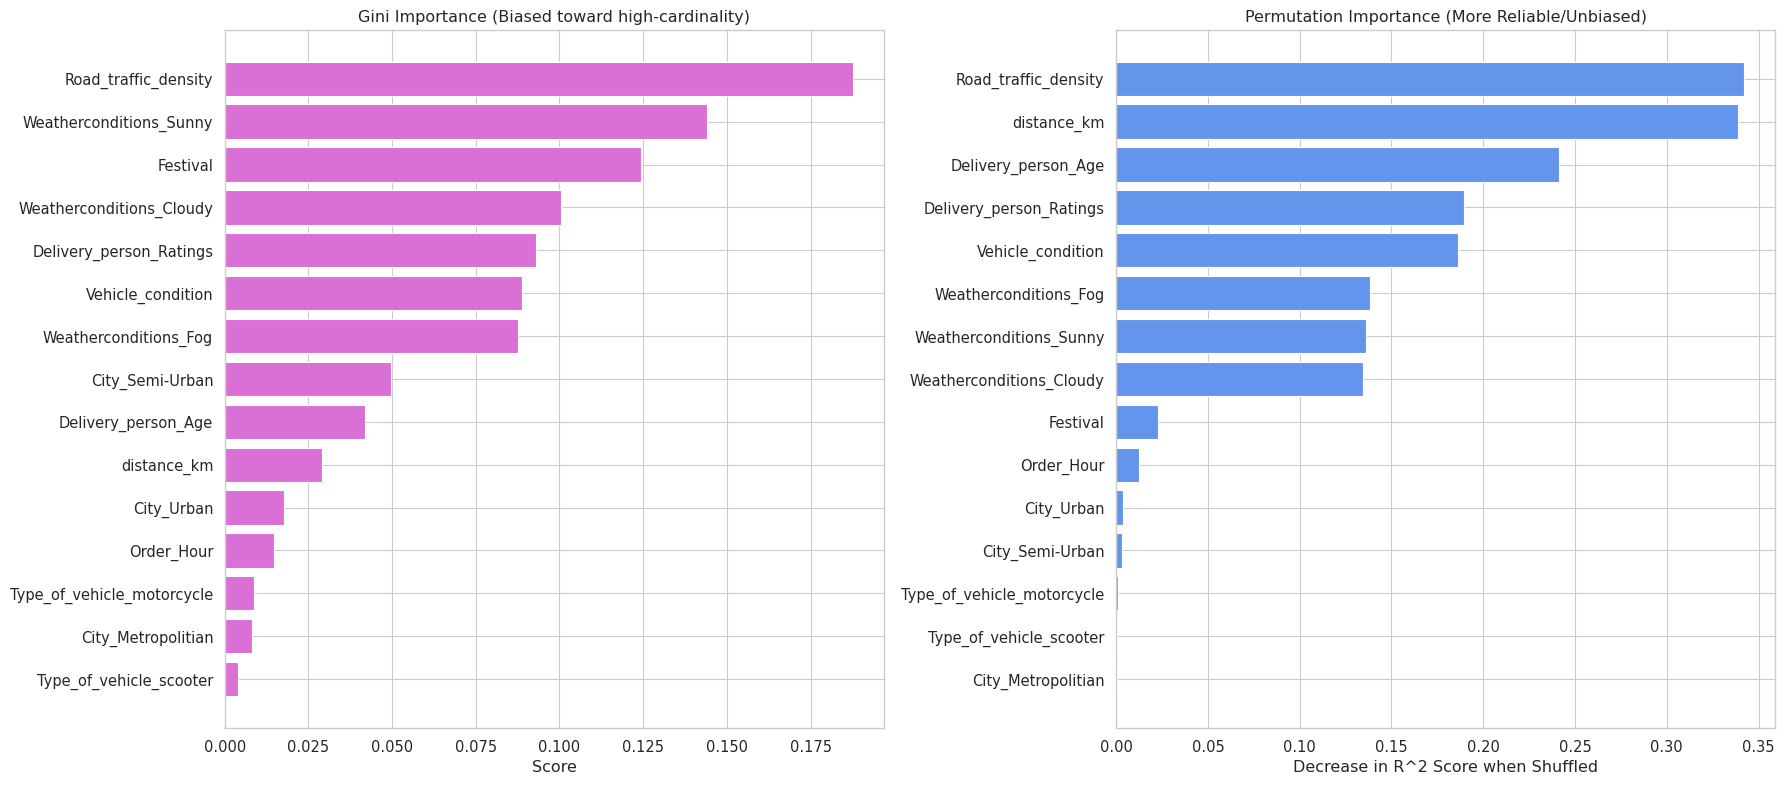

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

# 1. Feature Preparation Function
def prepare_features(data):
    # Select only numerical and boolean types
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

# 2. Feature Selection via Spearman Correlation
temp_numeric = prepare_features(df)
# Use Spearman to capture non-linear relationships
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()

threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()
if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

# 3. Data Splitting
X_all = prepare_features(df)[relevant_features]
y_all = df['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# Ensure test set has matching columns
X_test_final = prepare_features(df_test).reindex(columns=X_train.columns, fill_value=0)

# 4. XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('xgb', XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])

# 5. Training and Evaluation
xgb_pipeline.fit(X_train, y_train)
y_val_pred = xgb_pipeline.predict(X_val)

r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f"\n--- XGBoost Performance ---")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} minutes")

# 6. CALCULATING PERMUTATION IMPORTANCE (Solves the Gini Bias)
# This shuffles each feature to see how much the R^2 score drops
result = permutation_importance(
    xgb_pipeline, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

perm_importances = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

# 7. EXTRACTING GINI IMPORTANCE (Default XGBoost metric)
importances = xgb_pipeline.named_steps['xgb'].feature_importances_
gini_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 8. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot Gini Importance
ax1.barh(gini_importance_df['Feature'], gini_importance_df['Importance'], color='orchid')
ax1.set_title('Gini Importance (Biased toward high-cardinality)')
ax1.set_xlabel('Score')

# Plot Permutation Importance
ax2.barh(perm_importances['Feature'], perm_importances['Importance'], color='cornflowerblue')
ax2.set_title('Permutation Importance (More Reliable/Unbiased)')
ax2.set_xlabel('Decrease in R^2 Score when Shuffled')

plt.tight_layout()
plt.show()

In [ ]:
# --- Overfit Check ---
# Get predictions for BOTH sets
y_train_pred = xgb_pipeline.predict(X_train)
y_val_pred = xgb_pipeline.predict(X_val)

# Calculate R2 for both
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

# Calculate MAE for both
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"--- Overfitting Analysis ---")
print(f"Training R^2:   {r2_train:.4f} | Validation R^2:   {r2_val:.4f}")
print(f"Training MAE:   {mae_train:.2f} | Validation MAE:   {mae_val:.2f}")

# Logic check
gap = r2_train - r2_val
if gap > 0.10:
    print(f"\nSTATUS: High risk of Overfitting (Gap: {gap:.4f})")
    print("Action: Decrease max_depth or increase learning_rate's regularization.")
elif gap < 0.02:
    print(f"\nSTATUS: Good generalization (Gap: {gap:.4f})")
else:
    print(f"\nSTATUS: Acceptable variance (Gap: {gap:.4f})")

--- Overfitting Analysis ---
Training R^2:   0.8487 | Validation R^2:   0.8101
Training MAE:   2.92 | Validation MAE:   3.21

STATUS: Acceptable variance (Gap: 0.0385)


LightXGM with OHE

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[697]	valid_0's l1: 3.2316	valid_0's l2: 16.3989

--- LightGBM Performance ---
R^2 Score: 0.8097
MAE: 3.23 minutes


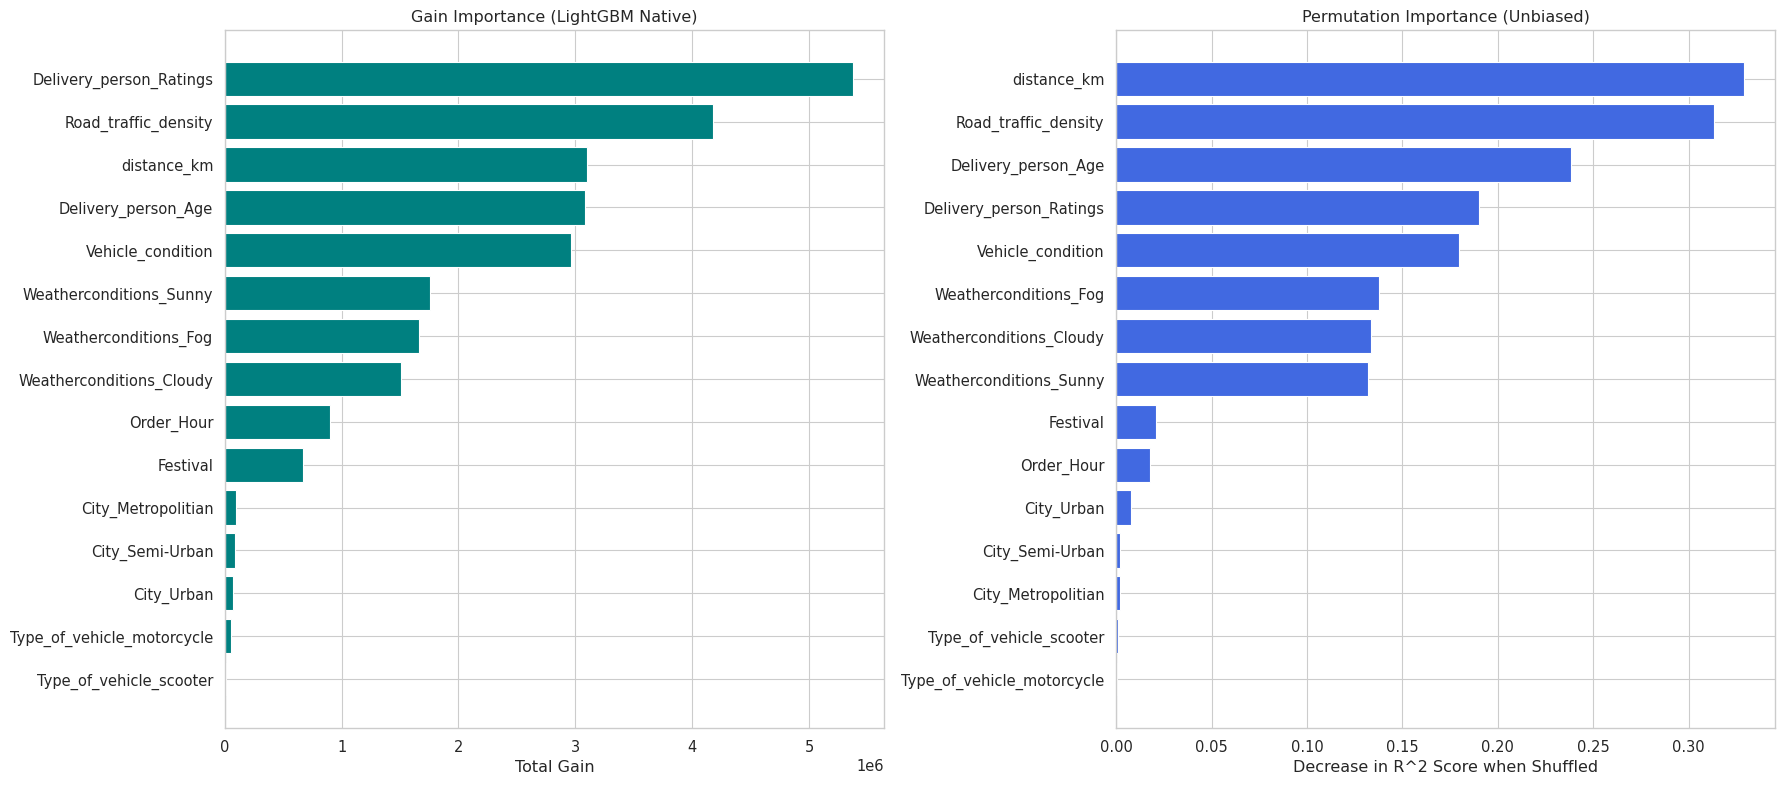

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

def prepare_features(data):
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

temp_numeric = prepare_features(df)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()

threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()
if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df)[relevant_features]
y_all = df['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

lgbm_pipeline = Pipeline([
    ('lgbm', LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        importance_type='gain',
        objective='regression',
        verbose=-1
    ))
])

lgbm_pipeline.fit(
    X_train, y_train,
    lgbm__eval_set=[(X_val, y_val)],
    lgbm__eval_metric='mae',
    lgbm__callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=0)
    ]
)

y_val_pred = lgbm_pipeline.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f"\n--- LightGBM Performance ---")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} minutes")

result = permutation_importance(
    lgbm_pipeline, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

perm_importances = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

importances = lgbm_pipeline.named_steps['lgbm'].feature_importances_
gain_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.barh(gain_importance_df['Feature'], gain_importance_df['Importance'], color='teal')
ax1.set_title('Gain Importance (LightGBM Native)')
ax1.set_xlabel('Total Gain')

# Permutation Importance Plot
ax2.barh(perm_importances['Feature'], perm_importances['Importance'], color='royalblue')
ax2.set_title('Permutation Importance (Unbiased)')
ax2.set_xlabel('Decrease in R^2 Score when Shuffled')

plt.tight_layout()
plt.show()

In [ ]:
# --- Overfit Check ---
# Get predictions for BOTH sets
y_train_pred = lgbm_pipeline.predict(X_train)
y_val_pred = lgbm_pipeline.predict(X_val)

# Calculate R2 for both
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

# Calculate MAE for both
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"--- Overfitting Analysis ---")
print(f"Training R^2:   {r2_train:.4f} | Validation R^2:   {r2_val:.4f}")
print(f"Training MAE:   {mae_train:.2f} | Validation MAE:   {mae_val:.2f}")

# Logic check
gap = r2_train - r2_val
if gap > 0.10:
    print(f"\nSTATUS: High risk of Overfitting (Gap: {gap:.4f})")
    print("Action: Decrease max_depth or increase learning_rate's regularization.")
elif gap < 0.02:
    print(f"\nSTATUS: Good generalization (Gap: {gap:.4f})")
else:
    print(f"\nSTATUS: Acceptable variance (Gap: {gap:.4f})")

--- Overfitting Analysis ---
Training R^2:   0.8421 | Validation R^2:   0.8148
Training MAE:   2.98 | Validation MAE:   3.18

STATUS: Acceptable variance (Gap: 0.0274)


Multi Spectural Model(OHE)

Training Multi-Spectral Model... (This may take a moment)

--- Multi-Spectral Stack Performance ---
Combined R^2 Score: 0.8155
Combined MAE: 3.18 minutes


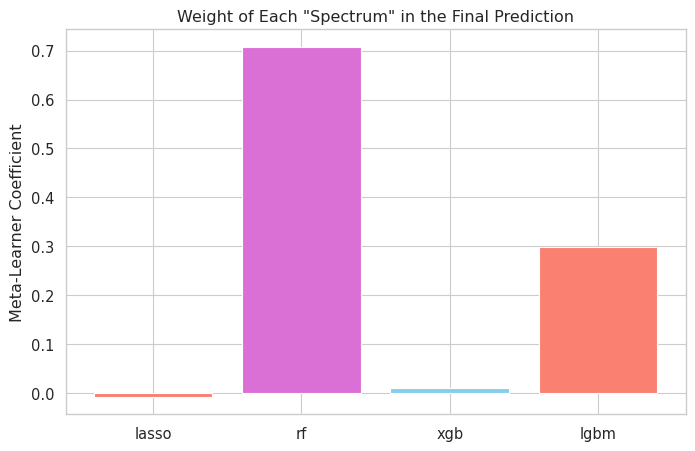

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. Feature Preparation (Same logic as your RF code)
def prepare_features(data):
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

# Feature Selection
temp_numeric = prepare_features(df)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()
threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()
if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df)[relevant_features]
y_all = df['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

skewed_cols = ['Delivery_person_Ratings', 'Order_Hour']
preprocessor = ColumnTransformer(
    transformers=[
        ('unskew', PowerTransformer(method='yeo-johnson'), skewed_cols)
    ],
    remainder='passthrough'
)
# 2. Define the Multi-Spectral "Base Spectrums"
# Spectrum 1: Linear (Lasso) - Good for simple distance/time relationships
# Spectrum 2: Parallel Trees (Random Forest) - Good for general stability
# Spectrum 3: Boosting (XGB) - Fast and handles categorical patterns perfectly
base_spectrums = [
    ('lasso', Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('lcv', LassoCV())])),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,           # XGBoost standard depth to match LGBM efficiency
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    )),
    ('lgbm', LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,         # Main complexity control for LGBM
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    importance_type='gain' # Makes importance comparable to XGBoost
    ))
]

# 3. Define the Meta-Model (The "Final Decider")
# Ridge is great as a meta-learner because it averages the predictions smartly
meta_learner = RidgeCV()

# 4. Initialize and Train the Stack
multi_spectral_model = StackingRegressor(
    estimators=base_spectrums,
    final_estimator=meta_learner,
    cv=5,      # Cross-validation
    n_jobs=-1
)

print("Training Multi-Spectral Model... (This may take a moment)")
multi_spectral_model.fit(X_train, y_train)

# 5. Evaluate Performance
y_val_pred = multi_spectral_model.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f"\n--- Multi-Spectral Stack Performance ---")
print(f"Combined R^2 Score: {r2:.4f}")
print(f"Combined MAE: {mae:.2f} minutes")

# 6. Visualize Meta-Learner Weights
# (Shows which model the stack trusts most)
final_weights = multi_spectral_model.final_estimator_.coef_
model_names = [name for name, _ in base_spectrums]

plt.figure(figsize=(8, 5))
plt.bar(model_names, final_weights, color=['salmon', 'orchid', 'skyblue'])
plt.title('Weight of Each "Spectrum" in the Final Prediction')
plt.ylabel('Meta-Learner Coefficient')
plt.show()

Data Transformation (Label Encoding - df_label)

In [ ]:
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   ID                           41953 non-null  object         
 1   Delivery_person_ID           41953 non-null  object         
 2   Delivery_person_Age          41953 non-null  Int64          
 3   Delivery_person_Ratings      41953 non-null  float64        
 4   Restaurant_latitude          41953 non-null  float64        
 5   Restaurant_longitude         41953 non-null  float64        
 6   Delivery_location_latitude   41953 non-null  float64        
 7   Delivery_location_longitude  41953 non-null  float64        
 8   Order_Date                   41953 non-null  datetime64[ns] 
 9   Time_Orderd                  41953 non-null  timedelta64[ns]
 10  Time_Order_picked            41953 non-null  object         
 11  Weatherconditions           

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Select the new original columns for encoding
cat_features = ['Weatherconditions', 'City', 'Type_of_vehicle','Type_of_order','Day_of_Week']

# Initialize and apply OrdinalEncoder
encoder = OrdinalEncoder()
df_label[cat_features] = encoder.fit_transform(df_label[cat_features])

# Print result to verify
print(df_label[['Weatherconditions', 'City', 'Type_of_vehicle','Type_of_order','Day_of_Week']].head())

   Weatherconditions  City  Type_of_vehicle  Type_of_order  Day_of_Week
0                4.0   2.0              2.0            3.0          2.0
1                3.0   0.0              3.0            3.0          0.0
2                2.0   2.0              2.0            1.0          2.0
3                4.0   0.0              2.0            0.0          5.0
4                0.0   0.0              3.0            3.0          2.0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Select the new original columns for encoding
cat_features = ['Weatherconditions', 'City', 'Type_of_vehicle','Type_of_order','Day_of_Week']

# Initialize and apply OrdinalEncoder
encoder = OrdinalEncoder()
df_test_label[cat_features] = encoder.fit_transform(df_test_label[cat_features])

# Print result to verify
print(df_test_label[['Weatherconditions', 'City', 'Type_of_vehicle','Type_of_order','Day_of_Week']].head())

   Weatherconditions  City  Type_of_vehicle  Type_of_order  Day_of_Week
0                4.0   0.0              1.0            1.0          6.0
1                5.0   0.0              2.0            3.0          5.0
2                3.0   0.0              2.0            1.0          4.0
3                1.0   0.0              3.0            2.0          2.0
4                4.0   0.0              3.0            1.0          3.0


In [ ]:
traffic_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Jam': 4
}

df_label['Road_traffic_density'] = df_label['Road_traffic_density'].map(traffic_mapping)
df_test_label['Road_traffic_density'] = df_test_label['Road_traffic_density'].map(traffic_mapping)

In [ ]:
df_label['multiple_deliveries'] = df_label['multiple_deliveries'].astype(int)
df_test_label['multiple_deliveries'] = df_test_label['multiple_deliveries'].astype(int)


In [ ]:
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   ID                           41953 non-null  object         
 1   Delivery_person_ID           41953 non-null  object         
 2   Delivery_person_Age          41953 non-null  Int64          
 3   Delivery_person_Ratings      41953 non-null  float64        
 4   Restaurant_latitude          41953 non-null  float64        
 5   Restaurant_longitude         41953 non-null  float64        
 6   Delivery_location_latitude   41953 non-null  float64        
 7   Delivery_location_longitude  41953 non-null  float64        
 8   Order_Date                   41953 non-null  datetime64[ns] 
 9   Time_Orderd                  41953 non-null  timedelta64[ns]
 10  Time_Order_picked            41953 non-null  object         
 11  Weatherconditions           

In [ ]:
ordinal_cols = [
    'Weatherconditions',
    'Type_of_order',
    'Type_of_vehicle',
    'City'
]

for col in ordinal_cols:
    df_label[col] = df_label[col].astype(int)
    df_test_label[col] = df_test_label[col].astype(int)

In [ ]:
df_label['Festival'] = df_label['Festival'].map({'No': 0, 'Yes': 1})
df_test_label['Festival'] = df_test_label['Festival'].map({'No': 0, 'Yes': 1})

In [ ]:
print(df_label[numeric_cols].skew())

Delivery_person_Age            0.008104
Delivery_person_Ratings         -2.7024
Restaurant_latitude            0.107042
Restaurant_longitude           1.192992
Delivery_location_latitude     0.107758
Delivery_location_longitude    1.192173
Vehicle_condition              0.073753
dtype: Float64


Random Forest (label encoding)


--- Random Forest Performance ---
R^2 Score: 0.7889
MAE: 3.37 minutes


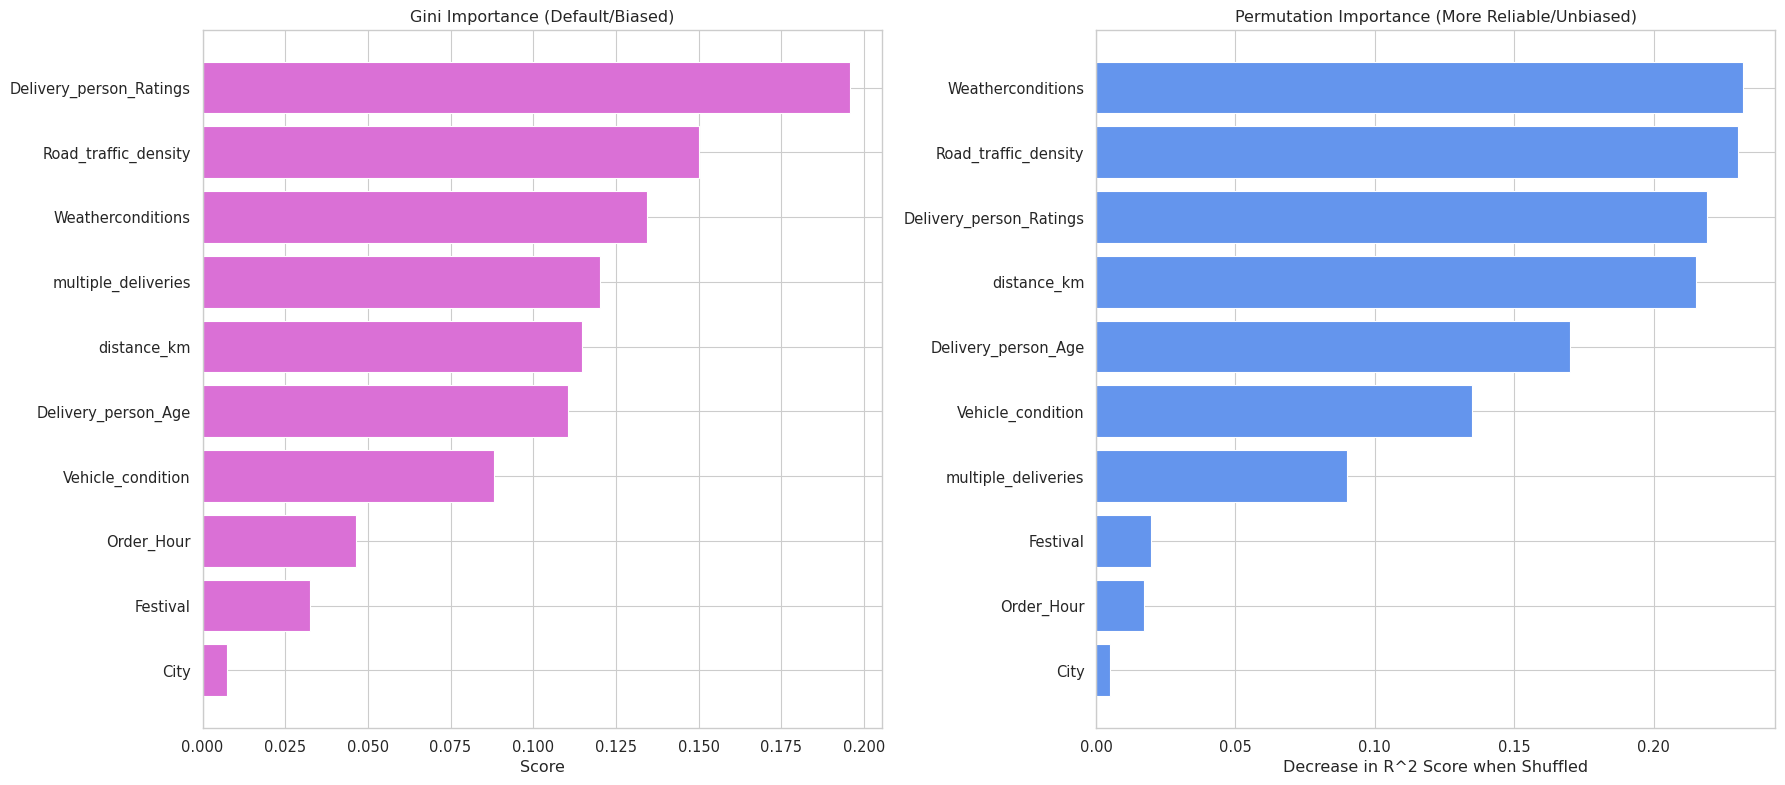

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance

def prepare_features(data):
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

temp_numeric = prepare_features(df_label)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()

threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()
if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df_label)[relevant_features]
y_all = df_label['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# skewed_features = [col for col in ['Delivery_person_Ratings', 'Order_Hour'] if col in relevant_features]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('power', PowerTransformer(method='yeo-johnson'), skewed_features)
#     ],
#     remainder='passthrough'
# )

rf_label_pipeline = Pipeline([
    # ('preprocessing', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_label_pipeline.fit(X_train, y_train)

y_val_pred = rf_label_pipeline.predict(X_val)
print(f"\n--- Random Forest Performance ---")
print(f"R^2 Score: {r2_score(y_val, y_val_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_val, y_val_pred):.2f} minutes")

result = permutation_importance(
    rf_label_pipeline, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

importances = rf_label_pipeline.named_steps['rf'].feature_importances_
gini_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.barh(gini_importance_df['Feature'], gini_importance_df['Importance'], color='orchid')
ax1.set_title('Gini Importance (Default/Biased)')
ax1.set_xlabel('Score')

ax2.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], color='cornflowerblue')
ax2.set_title('Permutation Importance (More Reliable/Unbiased)')
ax2.set_xlabel('Decrease in R^2 Score when Shuffled')

plt.tight_layout()
plt.show()

In [ ]:
y_train_pred = rf_label_pipeline.predict(X_train)
y_val_pred = rf_label_pipeline.predict(X_val)

r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"--- Overfitting Check: Random Forest ---")
print(f"{'Metric':<10} | {'Train Set':<10} | {'Validation Set':<15}")
print("-" * 45)
print(f"{'R2 Score':<10} | {r2_train:<10.4f} | {r2_val:<15.4f}")
print(f"{'MAE':<10} | {mae_train:<10.2f} | {mae_val:<15.2f}")

gap = r2_train - r2_val
if gap > 0.15:
    print(f"\nSTATUS: Significant Overfitting detected (Gap: {gap:.4f}).")
    print("Action: Consider decreasing 'max_depth' or increasing 'min_samples_leaf'.")
else:
    print(f"\nGood Generalization (Gap: {gap:.4f}).")

--- Overfitting Check: Random Forest ---
Metric     | Train Set  | Validation Set 
---------------------------------------------
R2 Score   | 0.8069     | 0.7889         
MAE        | 3.28       | 3.37           

Good Generalization (Gap: 0.0180).


In [ ]:
skewness = df_label.select_dtypes(include=['int64', 'float64']).skew()
print(skewness)

Delivery_person_Age            0.008104
Delivery_person_Ratings         -2.7024
Restaurant_latitude            0.107042
Restaurant_longitude           1.192992
Delivery_location_latitude     0.107758
Delivery_location_longitude    1.192173
Weatherconditions              0.041413
Road_traffic_density           0.240553
Vehicle_condition              0.073753
Type_of_order                 -0.011878
Type_of_vehicle                -0.20547
multiple_deliveries            0.293399
Festival                       6.932614
City                           1.331272
Time_taken(min)                0.481881
Prep_Time_Min                  0.007861
distance_km                    0.324622
Order_Hour                    -1.025474
Day_of_Week                   -0.012951
dtype: Float64


XGBoost (label Encoding)


--- XGBoost Performance ---
R^2 Score: 0.8194
MAE: 3.12 minutes


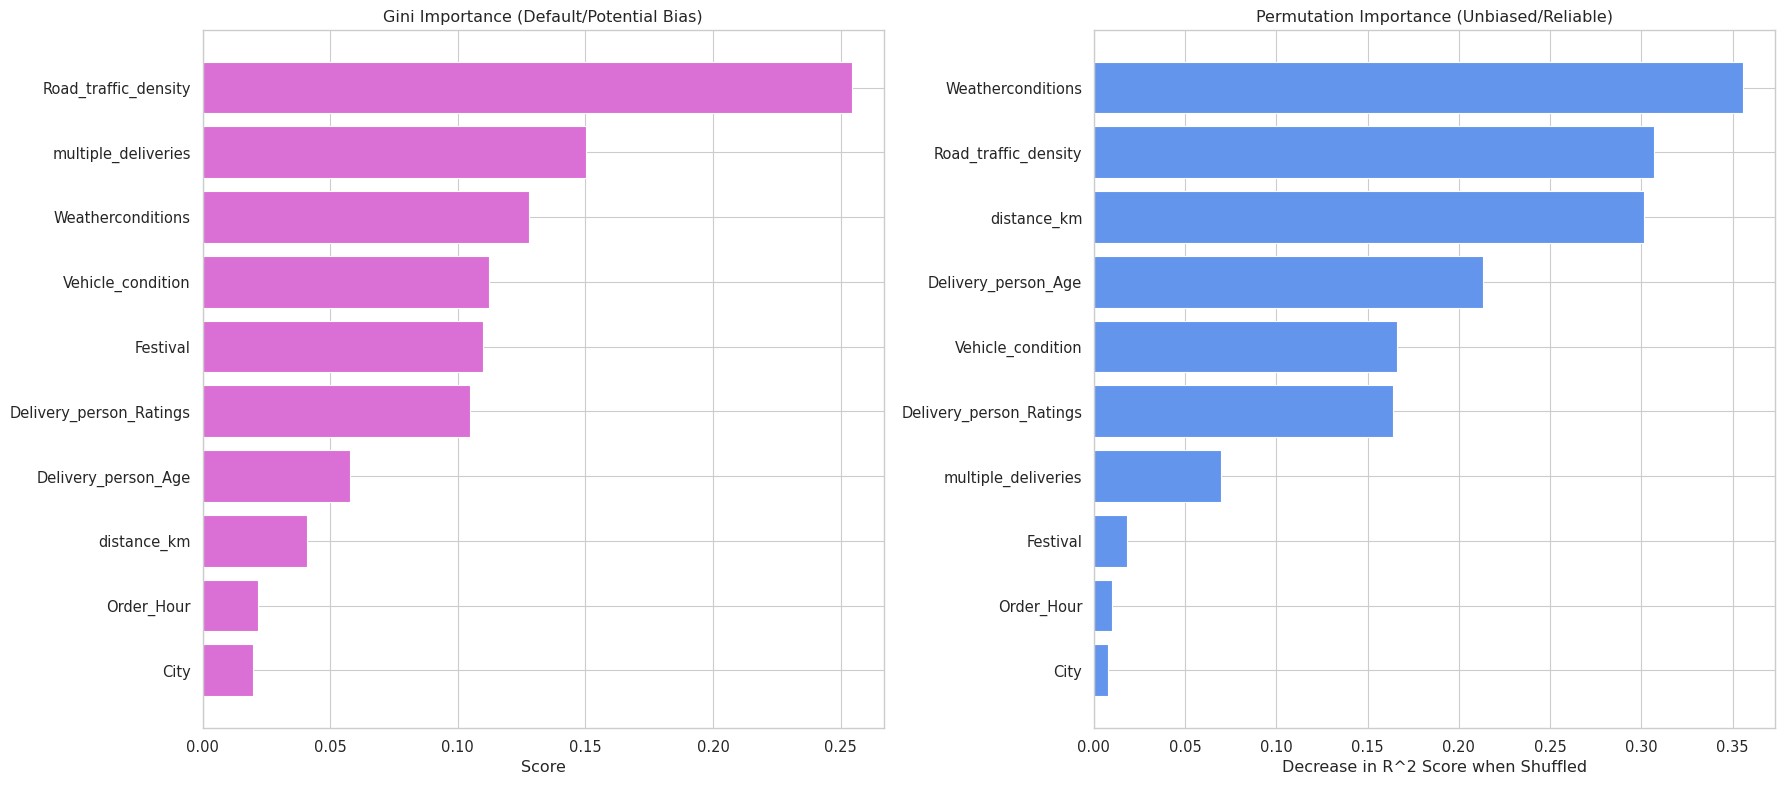

In [ ]:
from xgboost import XGBRegressor
def prepare_features(data):
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

temp_numeric = prepare_features(df_label)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()

threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()
if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df_label)[relevant_features]
y_all = df_label['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
X_test_final = prepare_features(df_test_label).reindex(columns=X_train.columns, fill_value=0)

skewed_features = ['Delivery_person_Ratings', 'Order_Hour']
preprocessor = ColumnTransformer(
    transformers=[
        ('power', PowerTransformer(method='yeo-johnson'), skewed_features)
    ],
    remainder='passthrough'
)

xgb_label_pipeline = Pipeline([
    # ('preprocessing', preprocessor),
    ('xgb_label', XGBRegressor(
        n_estimators=500,        # More trees than RF because they are smaller
        max_depth=6,             # XGBoost usually performs better with shallower trees
        learning_rate=0.05,      # Step size shrinkage to prevent overfitting
        subsample=0.8,           # Use 80% of data for each tree to add randomness
        colsample_bytree=0.8,    # Similar to max_features='sqrt'
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])

xgb_label_pipeline.fit(X_train, y_train)

y_val_pred = xgb_label_pipeline.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f"\n--- XGBoost Performance ---")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} minutes")

result = permutation_importance(
    xgb_label_pipeline, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

importances = xgb_label_pipeline.named_steps['xgb_label'].feature_importances_
gini_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Gini Importance Plot
ax1.barh(gini_importance_df['Feature'], gini_importance_df['Importance'], color='orchid')
ax1.set_title('Gini Importance (Default/Potential Bias)')
ax1.set_xlabel('Score')

# Permutation Importance Plot
ax2.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], color='cornflowerblue')
ax2.set_title('Permutation Importance (Unbiased/Reliable)')
ax2.set_xlabel('Decrease in R^2 Score when Shuffled')

plt.tight_layout()
plt.show()

In [ ]:
y_train_pred = xgb_label_pipeline.predict(X_train)
y_val_pred = xgb_label_pipeline.predict(X_val)

r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"--- Overfitting Check: XGBoost ---")
print(f"{'Metric':<10} | {'Train Set':<10} | {'Validation Set':<15}")
print("-" * 45)
print(f"{'R2 Score':<10} | {r2_train:<10.4f} | {r2_val:<15.4f}")
print(f"{'MAE':<10} | {mae_train:<10.2f} | {mae_val:<15.2f}")

gap = r2_train - r2_val
if gap > 0.15:
    print(f"\nSTATUS: Significant Overfitting detected (Gap: {gap:.4f}).")
    print("Action: Consider decreasing 'max_depth' or increasing 'min_samples_leaf'.")
else:
    print(f"\nGood Generalization (Gap: {gap:.4f}).")

--- Overfitting Check: XGBoost ---
Metric     | Train Set  | Validation Set 
---------------------------------------------
R2 Score   | 0.8580     | 0.8194         
MAE        | 2.82       | 3.12           

Good Generalization (Gap: 0.0386).


Light XGM(label Encoding)


--- LightGBM Performance ---
R^2 Score: 0.8189
MAE: 3.14 minutes


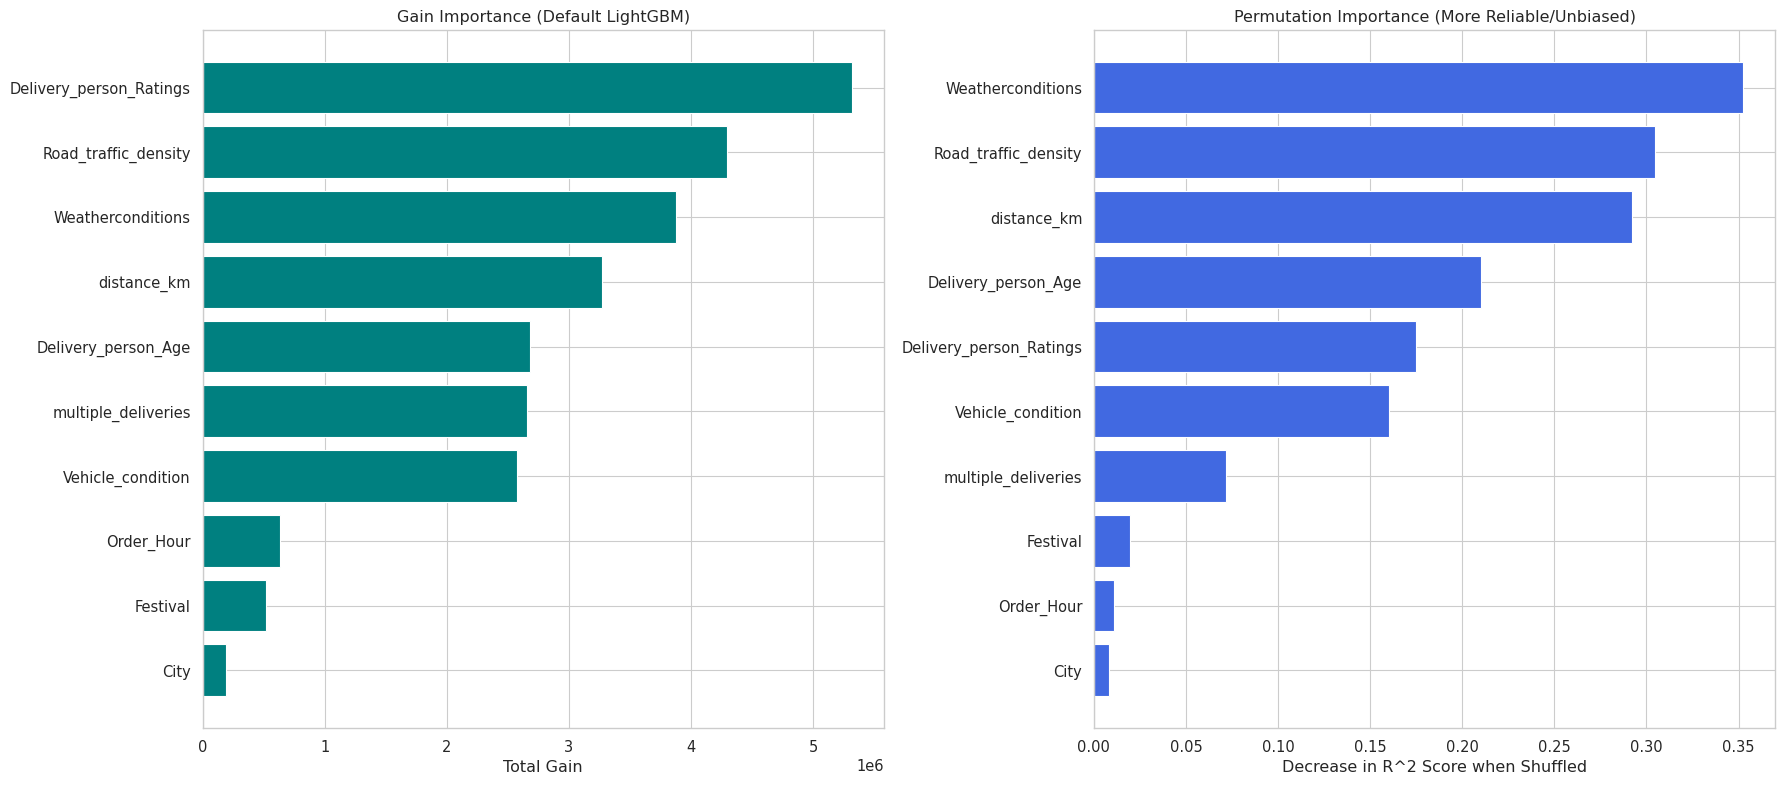

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.inspection import permutation_importance # Permutation အတွက် လိုအပ်သော library
from lightgbm import LGBMRegressor

def prepare_features(data):
    df_subset = data.select_dtypes(
        include=['bool', 'uint8', 'int64', 'float64']
    ).copy()

    for col in df_subset.columns:
        if df_subset[col].dtype in ['bool', 'uint8']:
            df_subset[col] = df_subset[col].astype(int)

    return df_subset

temp_numeric = prepare_features(df_label)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()

threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()

if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df_label)[relevant_features]
y_all = df_label['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

X_test_final = prepare_features(df_test_label)
X_test_final = X_test_final.reindex(columns=X_train.columns, fill_value=0)

lgbm_label_pipeline = Pipeline([
    ('lgbm_label', LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        importance_type='gain',
        verbose=-1
    ))
])

lgbm_label_pipeline.fit(X_train, y_train)

y_val_pred = lgbm_label_pipeline.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print("\n--- LightGBM Performance ---")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} minutes")

importances = lgbm_label_pipeline.named_steps['lgbm_label'].feature_importances_

gini_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

result = permutation_importance(
    lgbm_label_pipeline, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': relevant_features,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Gain Importance Plot
ax1.barh(gini_importance_df['Feature'], gini_importance_df['Importance'], color='teal')
ax1.set_title('Gain Importance (Default LightGBM)')
ax1.set_xlabel('Total Gain')

# Permutation Importance Plot
ax2.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], color='royalblue')
ax2.set_title('Permutation Importance (More Reliable/Unbiased)')
ax2.set_xlabel('Decrease in R^2 Score when Shuffled')

plt.tight_layout()
plt.show()

In [ ]:
y_train_pred = lgbm_label_pipeline.predict(X_train)
y_val_pred = lgbm_label_pipeline.predict(X_val)

r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"--- Overfitting Check: XGBoost ---")
print(f"{'Metric':<10} | {'Train Set':<10} | {'Validation Set':<15}")
print("-" * 45)
print(f"{'R2 Score':<10} | {r2_train:<10.4f} | {r2_val:<15.4f}")
print(f"{'MAE':<10} | {mae_train:<10.2f} | {mae_val:<15.2f}")

gap = r2_train - r2_val
if gap > 0.15:
    print(f"\nSTATUS: Significant Overfitting detected (Gap: {gap:.4f}).")
    print("Action: Consider decreasing 'max_depth' or increasing 'min_samples_leaf'.")
else:
    print(f"\nGood Generalization (Gap: {gap:.4f}).")

--- Overfitting Check: XGBoost ---
Metric     | Train Set  | Validation Set 
---------------------------------------------
R2 Score   | 0.8539     | 0.8189         
MAE        | 2.86       | 3.14           

Good Generalization (Gap: 0.0349).


Multi Spectural (Label Encoding)

Training Multi-Spectral Model... (This may take a moment)

--- Multi-Spectral Stack Performance ---
Combined R^2 Score: 0.8228
Combined MAE: 3.10 minutes


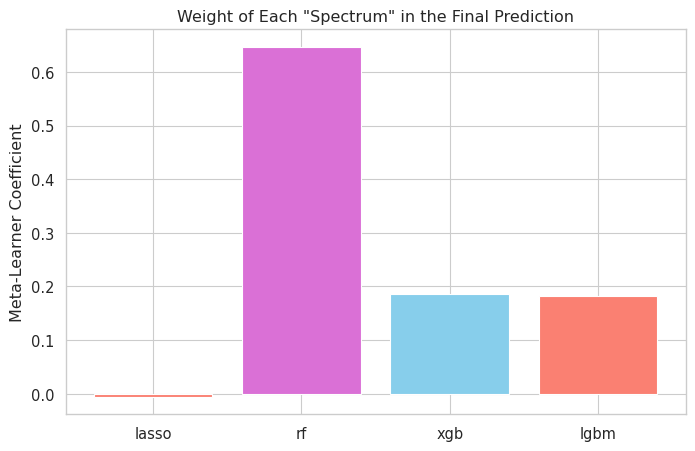

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. Feature Preparation (Same logic as your RF code)
def prepare_features(data):
    df_subset = data.select_dtypes(include=['bool', 'uint8', 'int64', 'float64']).copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'bool' or df_subset[col].dtype == 'uint8':
            df_subset[col] = df_subset[col].astype(int)
    return df_subset

# Feature Selection
temp_numeric = prepare_features(df_label)
spearman_corr = temp_numeric.corr(method='spearman')['Time_taken(min)'].abs()
threshold = 0.1
relevant_features = spearman_corr[spearman_corr > threshold].index.tolist()
if 'Time_taken(min)' in relevant_features:
    relevant_features.remove('Time_taken(min)')

X_all = prepare_features(df_label)[relevant_features]
y_all = df_label['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

skewed_features = ['Delivery_person_Ratings', 'Order_Hour']
preprocessor = ColumnTransformer(
    transformers=[
        ('power', PowerTransformer(method='yeo-johnson'), skewed_features)
    ],
    remainder='passthrough'
)

# 2. Define the Multi-Spectral "Base Spectrums"
# Spectrum 1: Linear (Lasso) - Good for simple distance/time relationships
# Spectrum 2: Parallel Trees (Random Forest) - Good for general stability
# Spectrum 3: Boosting (XGB) - Fast and handles categorical patterns perfectly
base_spectrums = [
    ('lasso', Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('lcv', LassoCV())])),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,           # XGBoost standard depth to match LGBM efficiency
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    )),
    ('lgbm', LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,         # Main complexity control for LGBM
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    importance_type='gain' # Makes importance comparable to XGBoost
    ))
]

# 3. Define the Meta-Model (The "Final Decider")
# Ridge is great as a meta-learner because it averages the predictions smartly
meta_learner = RidgeCV()

# 4. Initialize and Train the Stack
multi_spectral_model = StackingRegressor(
    estimators=base_spectrums,
    final_estimator=meta_learner,
    cv=5,      # Cross-validation
    n_jobs=-1
)

print("Training Multi-Spectral Model... (This may take a moment)")
multi_spectral_model.fit(X_train, y_train)

# 5. Evaluate Performance
y_val_pred = multi_spectral_model.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f"\n--- Multi-Spectral Stack Performance ---")
print(f"Combined R^2 Score: {r2:.4f}")
print(f"Combined MAE: {mae:.2f} minutes")

# 6. Visualize Meta-Learner Weights
# (Shows which model the stack trusts most)
final_weights = multi_spectral_model.final_estimator_.coef_
model_names = [name for name, _ in base_spectrums]

plt.figure(figsize=(8, 5))
plt.bar(model_names, final_weights, color=['salmon', 'orchid', 'skyblue'])
plt.title('Weight of Each "Spectrum" in the Final Prediction')
plt.ylabel('Meta-Learner Coefficient')
plt.show()

In [ ]:
# def reverse_ohe(df, prefix):
#     # Find all columns that start with the prefix (e.g., 'Weatherconditions_')
#     cols = [c for c in df.columns if c.startswith(prefix)]

#     # For each row, find which column is True/1 and extract the suffix
#     # Example: 'Weatherconditions_Sunny' becomes 'Sunny'
#     df[prefix[:-1]] = df[cols].idxmax(axis=1).str.replace(prefix, "")

#     # Optional: Drop the OHE columns once you have the original back
#     df = df.drop(columns=cols)

#     return df

# # Apply to your specific columns
# df = reverse_ohe(df, 'Weatherconditions_')
# df = reverse_ohe(df, 'City_')
# df = reverse_ohe(df, 'Type_of_vehicle_')
# df = reverse_ohe(df, 'Type_of_order_')
# df = reverse_ohe(df, 'Day_of_Week_')

In [ ]:
print(df.select_dtypes(include=['object', 'category']).nunique())

ID                      41953
Delivery_person_ID       1170
Time_Order_picked         193
Weatherconditions           6
Road_traffic_density        4
Type_of_order               4
Type_of_vehicle             4
multiple_deliveries         4
Festival                    2
City                        3
Day_of_Week                 7
dtype: int64


Random Forest Model with OHE

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# rf_features = [
#     'Road_traffic_density',   # 0.41
#     'multiple_deliveries',     # 0.38
#     'Delivery_person_Ratings',# -0.33
#     'distance_km',            # 0.32
#     'Delivery_person_Age',    # 0.29
#     'Festival',               # 0.29
#     'Vehicle_condition',      # -0.24
#     'Weatherconditions_Sunny',# -0.21
#     'City_Urban',             # -0.19
#     'Order_Hour',             # 0.18
#     'Type_of_vehicle_motorcycle', # 0.16
#     'City_Semi-Urban',        # 0.15
#     'Type_of_vehicle_scooter',# -0.14
#     'Weatherconditions_Fog'   # 0.12
# ]
# X = df[rf_features]
# y = df['Time_taken(min)']

# # 1. Initialize the Random Forest Model
# # n_estimators=100 means we are building 100 different trees
# # random_state=42 ensures you get the same result every time
# rf_model = RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_leaf=10, random_state=42)

# # 2. Run 5-Fold Cross-Validation (On the 80% Training Data)
# # This checks if the Forest is stable
# rf_cv_mae = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
# rf_cv_mse = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
# rf_cv_rmse = np.sqrt(rf_cv_mse)

# print(f"--- Random Forest: 5-Fold CV Results ---")
# print(f"MAE per Fold: {rf_cv_mae}")
# print(f"Average CV MAE: {rf_cv_mae.mean():.2f} minutes")
# print(f"Average CV RMSE: {rf_cv_rmse.mean():.2f} minutes")
# print(f"Stability (Std Dev): {rf_cv_mae.std():.4f}\n")

# # 3. Final Training and Testing
# rf_model.fit(X_train, y_train)
# rf_test_preds = rf_model.predict(X_test)

# # 4. Final Performance Metrics
# rf_mae_test = mean_absolute_error(y_test, rf_test_preds)
# rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_test_preds))
# rf_r2_test = r2_score(y_test, rf_test_preds)

# print(f"Random Forest: Final Test Results (20%)")
# print(f"Test MAE: {rf_mae_test:.2f} minutes")
# print(f"Test RMSE: {rf_rmse_test:.2f} minutes")
# print(f"Test R2 Score: {rf_r2_test:.4f}")

random forest with OHE(train, test data)

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # --- 1. FEATURE SELECTION ---
# rf_features = [
#     'Road_traffic_density',
#     'multiple_deliveries',
#     'Delivery_person_Ratings',
#     'distance_km',
#     'Delivery_person_Age',
#     'Festival',
#     'Vehicle_condition',
#     'Weatherconditions_Sunny',
#     'City_Urban',
#     'Order_Hour',
#     'Type_of_vehicle_motorcycle',
#     'City_Semi-Urban',
#     'Type_of_vehicle_scooter',
#     'Weatherconditions_Fog'
# ]

# # --- 2. PREPARE TRAINING DATA (from df) ---
# X = df[rf_features]
# y = df['Time_taken(min)']


# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # --- 3. PREPARE TEST DATA (from df_test) ---
# X_test_final = df_test[rf_features].copy()

# # --- 4. INITIALIZE MODEL ---
# rf_model = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_leaf=10,
#     random_state=42,
#     n_jobs=-1
# )

# # --- 5. RUN 5-FOLD CROSS-VALIDATION (On Training Data) ---
# cv_mae = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
# print(f"--- Random Forest: 5-Fold CV Results ---")
# print(f"Average CV MAE: {cv_mae.mean():.2f} minutes")
# print(f"Stability (Std Dev): {cv_mae.std():.4f}\n")

# # --- 6. TRAIN ON FULL TRAINING SET & VALIDATE ---
# rf_model.fit(X_train, y_train)
# val_preds = rf_model.predict(X_val)

# val_mae = mean_absolute_error(y_val, val_preds)
# val_r2 = r2_score(y_val, val_preds)

# print(f"--- Validation Performance (20% of df) ---")
# print(f"Validation MAE: {val_mae:.2f} minutes")
# print(f"Validation R2 Score: {val_r2:.4f}\n")



# print(f"--- Final Predictions for df_test ---")
# print(df_test[['Predicted_Time_taken(min)']].head())



--- Random Forest: 5-Fold CV Results ---
Average CV MAE: 3.63 minutes
Stability (Std Dev): 0.0255

--- Validation Performance (20% of df) ---
Validation MAE: 3.59 minutes
Validation R2 Score: 0.7576

--- Final Predictions for df_test ---
   Predicted_Time_taken(min)
0                  20.256456
1                  32.058852
2                  31.364059
3                  29.786187
4                  23.017306


check overfit in Random forest(OHE)

In [ ]:
# # --- 6. TRAIN ON FULL TRAINING SET & VALIDATE ---
# rf_model.fit(X_train, y_train)

# train_preds = rf_model.predict(X_train)
# train_mae = mean_absolute_error(y_train, train_preds)
# train_r2 = r2_score(y_train, train_preds)

# val_preds = rf_model.predict(X_val)
# val_mae = mean_absolute_error(y_val, val_preds)
# val_r2 = r2_score(y_val, val_preds)

# print(f"--- Overfitting Check ---")
# print(f"Training   MAE: {train_mae:.2f} | R2: {train_r2:.4f}")
# print(f"Validation MAE: {val_mae:.2f} | R2: {val_r2:.4f}")

# # Overfitting Analysis
# mae_diff = val_mae - train_mae
# r2_diff = train_r2 - val_r2

# print(f"\nAnalysis:")
# if mae_diff > 1.0 or r2_diff > 0.10:
#     print(f"[!] Warning: Potential Overfitting. The gap between Train and Val is too large.")
# elif train_mae > 5.0:
#     print(f"[!] Warning: Potential Underfitting. The model is too simple.")
# else:
#     print(f"[+] Model is well-generalized. Train and Val results are close.")

--- Overfitting Check ---
Training   MAE: 3.50 | R2: 0.7747
Validation MAE: 3.59 | R2: 0.7576

Analysis:
[+] Model is well-generalized. Train and Val results are close.


Normalized value to Original Value


In [ ]:
# normalized_data = df[features_to_normalize]
# df[features_to_normalize] = std_scaler.inverse_transform(normalized_data)
# print("The Original value is : ")
# print(df[features_to_normalize].head())

NameError: name 'features_to_normalize' is not defined

In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions_Sunny,Weatherconditions_Windy,City_Semi-Urban,City_Urban,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,0 days 11:30:00,...,True,False,False,True,False,True,False,False,False,True
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,0 days 19:45:00,...,False,False,False,False,False,False,True,False,False,True
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,0 days 08:30:00,...,False,False,False,True,False,True,False,True,False,False
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,0 days 18:00:00,...,True,False,False,False,False,True,False,False,False,False
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,0 days 13:30:00,...,False,False,False,False,False,False,True,False,False,True


Random Forest with Label Encoding.

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# rf_label_features = [
#     'Delivery_person_Age',
#     'Delivery_person_Ratings',
#     'Road_traffic_density',
#     'Vehicle_condition',
#     'Festival',
#     'distance_km',
#     'Order_Hour',
#     'Weatherconditions',
#     'City',
#     'Type_of_vehicle'
# ]
# X = df[rf_label_features]
# y = df['Time_taken(min)']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 1. Initialize the Random Forest Model
# # n_estimators=100 means we are building 100 different trees
# # random_state=42 ensures you get the same result every time
# rf_model = RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_leaf=10, random_state=42, n_jobs=-1)

# # 2. Run 5-Fold Cross-Validation (On the 80% Training Data)
# # This checks if the Forest is stable
# rf_cv_mae = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
# rf_cv_mse = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
# rf_cv_rmse = np.sqrt(rf_cv_mse)

# print(f"--- Random Forest: 5-Fold CV Results ---")
# print(f"MAE per Fold: {rf_cv_mae}")
# print(f"Average CV MAE: {rf_cv_mae.mean():.2f} minutes")
# print(f"Average CV RMSE: {rf_cv_rmse.mean():.2f} minutes")
# print(f"Stability (Std Dev): {rf_cv_mae.std():.4f}\n")

# # 3. Final Training and Testing
# rf_model.fit(X_train, y_train)
# rf_test_preds = rf_model.predict(X_test)

# # 4. Final Performance Metrics
# rf_mae_test = mean_absolute_error(y_test, rf_test_preds)
# rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_test_preds))
# rf_r2_test = r2_score(y_test, rf_test_preds)

# print(f"--- Random Forest: Final Test Results (20%) ---")
# print(f"Test MAE: {rf_mae_test:.2f} minutes")
# print(f"Test RMSE: {rf_rmse_test:.2f} minutes")
# print(f"Test R2 Score: {rf_r2_test:.4f}")

--- Random Forest: 5-Fold CV Results ---
MAE per Fold: [3.20675268 3.19752147 3.20925199 3.23858808 3.18093301]
Average CV MAE: 3.21 minutes
Average CV RMSE: 4.02 minutes
Stability (Std Dev): 0.0188

--- Random Forest: Final Test Results (20%) ---
Test MAE: 3.21 minutes
Test RMSE: 4.04 minutes
Test R2 Score: 0.8103


check overfit or not in Random Forest(Label encoding)

In [ ]:
# # 1. Get predictions for the Training data
# rf_train_preds = rf_model.predict(X_train)

# # 2. Calculate Training metrics
# rf_mae_train = mean_absolute_error(y_train, rf_train_preds)
# rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_train_preds))
# rf_r2_train = r2_score(y_train, rf_train_preds)

# # 3. Print Comparison
# print(f"--- Random Forest: Overfitting Check ---")
# print(f"Train MAE: {rf_mae_train:.2f} | Test MAE: {rf_mae_test:.2f}")
# print(f"Train R2:  {rf_r2_train:.4f} | Test R2:  {rf_r2_test:.4f}")

--- Random Forest: Overfitting Check ---
Train MAE: 3.02 | Test MAE: 3.21
Train R2:  0.8369 | Test R2:  0.8103


In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# rf_label_features = [
#     'Delivery_person_Age',
#     'Delivery_person_Ratings',
#     'Road_traffic_density',
#     'Vehicle_condition',
#     'Festival',
#     'distance_km',
#     'Order_Hour',
#     'Weatherconditions'
# ]
# X = df[rf_label_features]
# y = df['Time_taken(min)']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 1. Initialize the Random Forest Model
# # n_estimators=100 means we are building 100 different trees
# # random_state=42 ensures you get the same result every time
# rf_model = RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_leaf=5, random_state=42, n_jobs=-1)

# # 2. Run 5-Fold Cross-Validation (On the 80% Training Data)
# # This checks if the Forest is stable
# rf_cv_mae = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
# rf_cv_mse = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
# rf_cv_rmse = np.sqrt(rf_cv_mse)

# print(f"--- Random Forest: 5-Fold CV Results ---")
# print(f"MAE per Fold: {rf_cv_mae}")
# print(f"Average CV MAE: {rf_cv_mae.mean():.2f} minutes")
# print(f"Average CV RMSE: {rf_cv_rmse.mean():.2f} minutes")
# print(f"Stability (Std Dev): {rf_cv_mae.std():.4f}\n")

# # 3. Final Training and Testing
# rf_model.fit(X_train, y_train)
# rf_test_preds = rf_model.predict(X_test)

# # 4. Final Performance Metrics
# rf_mae_test = mean_absolute_error(y_test, rf_test_preds)
# rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_test_preds))
# rf_r2_test = r2_score(y_test, rf_test_preds)

# print(f"--- Random Forest: Final Test Results (20%) ---")
# print(f"Test MAE: {rf_mae_test:.2f} minutes")
# print(f"Test RMSE: {rf_rmse_test:.2f} minutes")
# print(f"Test R2 Score: {rf_r2_test:.4f}")

--- Random Forest: 5-Fold CV Results ---
MAE per Fold: [3.21495917 3.20125253 3.21184485 3.24030333 3.17327507]
Average CV MAE: 3.21 minutes
Average CV RMSE: 4.02 minutes
Stability (Std Dev): 0.0217

--- Random Forest: Final Test Results (20%) ---
Test MAE: 3.21 minutes
Test RMSE: 4.03 minutes
Test R2 Score: 0.8116


In [ ]:
# import xgboost as xgb
# xgb_model = xgb.XGBRegressor(
#     n_estimators=500,       # Number of boosting rounds
#     learning_rate=0.01,     # Step size shrinkage to prevent overfitting
#     max_depth=8,            # Depth of each tree
#     subsample=0.9,          # Use 80% of data per tree to add robustness
#     colsample_bytree=0.8,   # Use 80% of features per tree
#     random_state=42,
#     n_jobs=-1               # Use all CPU cores
# )

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='neg_mean_absolute_error')

# xgb_model.fit(X_train, y_train)

# # 3. Make Predictions
# xgb_train_preds = xgb_model.predict(X_train)
# xgb_test_preds = xgb_model.predict(X_test)

# # 4. Evaluate Performance
# # Comparing Train vs Test to check for overfitting
# train_r2 = r2_score(y_train, xgb_train_preds)
# test_r2 = r2_score(y_test, xgb_test_preds)
# test_mse = mean_squared_error(y_test, xgb_test_preds)
# test_rmse = np.sqrt(test_mse)
# test_mae = mean_absolute_error(y_test, xgb_test_preds)
# cv_mae_scores = -cv_scores

# print(f"--- XGBoost 5-Fold CV Results (MAE) ---")
# print(f"Scores for each fold: {cv_mae_scores}")
# print(f"Average CV MAE: {cv_mae_scores.mean():.2f} minutes")
# print(f"Standard Deviation: {cv_mae_scores.std():.2f}")

# print(f"--- XGBoost Performance ---")
# print(f"Train R2: {train_r2:.4f}")
# print(f"Test R2:  {test_r2:.4f}")
# print(f"Test RMSE: {test_rmse:.2f}")
# print(f"Test MAE: {test_mae:.2f} minutes")

--- XGBoost 5-Fold CV Results (MAE) ---
Scores for each fold: [3.22392726 3.2520566  3.21653962 3.19716167 3.22693801]
Average CV MAE: 3.22 minutes
Standard Deviation: 0.02
--- XGBoost Performance ---
Train R2: 0.8419
Test R2:  0.8100
Test RMSE: 4.05
Test MAE: 3.22 minutes


In [ ]:
import pandas as pd
import numpy as np

new_delivery_data = {
    'Delivery_person_Age': 37,
    'Delivery_person_Ratings': 4.7,
    'Restaurant_latitude': 12.976,
    'Restaurant_longitude': 80.2219,
    'Delivery_location_latitude': 13.006,
    'Delivery_location_longitude': 80.2519,
    'Road_traffic_density': 'Medium',
    'Weatherconditions': 'Cloudy',
    'Vehicle_condition': 2,
    'Multiple_deliveries': 0,
    'Festival': 'No',
    'Order_Hour' : '18:35:00'
}

df_new_value = pd.DataFrame([new_delivery_data])

def calculate_distance(rest_lat1, rest_lon1, deli_lat2, deli_lon2):
    Earth_Radius= 6371  # Earth radius in km
    d_lat = np.radians(deli_lat2 - rest_lat1)
    d_lon = np.radians(deli_lon2 - rest_lon1)
    a = np.sin(d_lat/2)**2 + np.cos(np.radians(rest_lat1)) * np.cos(np.radians(deli_lat2)) * np.sin(d_lon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return Earth_Radius * c

df_new_value['distance_km'] = calculate_distance(
    df_new_value['Restaurant_latitude'], df_new_value['Restaurant_longitude'],
    df_new_value['Delivery_location_latitude'], df_new_value['Delivery_location_longitude']
)

traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
df_new_value['Road_traffic_density'] = df_new_value['Road_traffic_density'].map(traffic_map)

weather_map = {'Sunny': 0, 'Stormy': 1, 'Sandstorms': 2, 'Cloudy': 3, 'Fog': 4, 'Windy': 5}
df_new_value['Weatherconditions'] = df_new_value['Weatherconditions'].map(weather_map)
df_new_value['Festival'] = df_new_value['Festival'].map({'Yes': 1, 'No': 0})

time_obj = pd.to_timedelta(df_new_value['Order_Hour'])
df_new_value['Order_Hour'] = time_obj.dt.components['hours'].astype(int)

df_new = df_new_value[X_train.columns]

predicted_time_xgb = xgb_model.predict(df_new)
predicted_time_rf = rf_model.predict(df_new)


print(f"Predicted Delivery Time by XGBoost: {predicted_time_xgb[0]:.2f} minutes")
print(f"Predicted Delivery Time by Random Forest: {predicted_time_rf[0]:.2f} minutes")

Predicted Delivery Time by XGBoost: 19.30 minutes
Predicted Delivery Time by Random Forest: 19.81 minutes


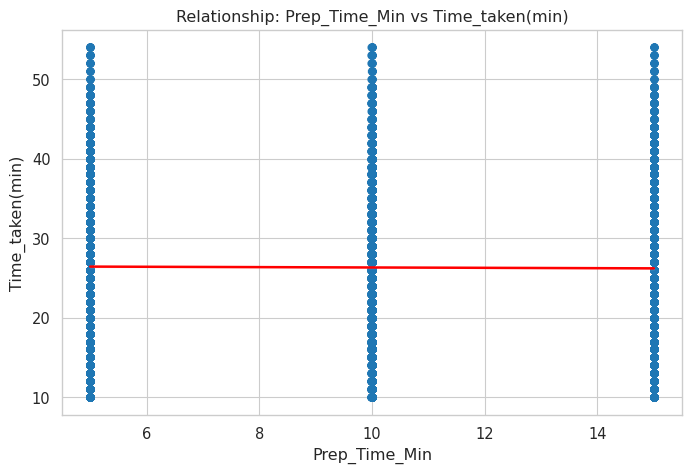

Correlation Coefficient: -0.0094
P-value: 0.0550 (If < 0.05, the relationship is significant)


In [ ]:
# Define your two columns
feat1 = 'Prep_Time_Min'
feat2 = 'Time_taken(min)'

# 1. Visualize the relationship
plt.figure(figsize=(8, 5))
sns.regplot(x=feat1, y=feat2, data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Relationship: {feat1} vs {feat2}')
plt.show()

# 2. Get the exact Correlation Coefficient and P-value
corr, p_value = pearsonr(df[feat1], df[feat2])
print(f"Correlation Coefficient: {corr:.4f}")
print(f"P-value: {p_value:.4f} (If < 0.05, the relationship is significant)")

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
weather_map = {'Sunny': 0, 'Stormy': 1, 'Sandstorms': 2, 'Cloudy': 3, 'Fog': 4, 'Windy': 5}


style = {'description_width': 'initial'}
layout = widgets.Layout(width='300px')

age_widget = widgets.IntText(value=30, description='Delivery Person Age:', style=style, layout=layout)
rating_widget = widgets.FloatText(value=4.5, description='Delivery Person Rating:', style=style, layout=layout)

res_lat_widget = widgets.FloatText(value=12.97, description='Restaurant Lat:', style=style, layout=layout)
res_lon_widget = widgets.FloatText(value=77.59, description='Restaurant Lon:', style=style, layout=layout)

del_lat_widget = widgets.FloatText(value=13.03, description='Delivery Lat:', style=style, layout=layout)
del_lon_widget = widgets.FloatText(value=77.60, description='Delivery Lon:', style=style, layout=layout)

traffic_widget = widgets.Dropdown(
    options=['Low', 'Medium', 'High', 'Jam'],
    value='Medium',
    description='Traffic:',
    style=style, layout=layout
)

weather_widget = widgets.Dropdown(
    options=['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy'],
    value='Cloudy',
    description='Weather:',
    style=style, layout=layout
)

vehicle_widget = widgets.Dropdown(
    options=[0,1,2,3],
    value=2,
    description='Vehicle Condition:',
    style=style, layout=layout
)

multi_widget = widgets.Dropdown(
    options=[0,1,2,3],
    value=1,
    description='Multiple Deliveries:',
    style=style, layout=layout
)

fest_widget = widgets.Dropdown(
    options=['Yes','No'],
    value='No',
    description='Festival:',
    style=style, layout=layout
)

time_widget = widgets.Text(
    value='18:30:00',
    description='Order Time (HH:MM:SS):',
    style=style, layout=layout
)

predict_btn = widgets.Button(
    description='Predict ETA',
    button_style='primary',
    layout=widgets.Layout(width='600px', height='40px')
)

output_label = widgets.Output()

def run_prediction(b):
    with output_label:
        clear_output()
        try:
            input_data = {
                'Delivery_person_Age': age_widget.value,
                'Delivery_person_Ratings': rating_widget.value,
                'Road_traffic_density': traffic_widget.value,
                'Weatherconditions': weather_widget.value,
                'Vehicle_condition': vehicle_widget.value,
                'Multiple_deliveries': multi_widget.value,
                'Festival': fest_widget.value,
                'Order_Hour': time_widget.value,
                'Restaurant_latitude': res_lat_widget.value,
                'Restaurant_longitude': res_lon_widget.value,
                'Delivery_location_latitude': del_lat_widget.value,
                'Delivery_location_longitude': del_lon_widget.value
            }

            df_input = pd.DataFrame([input_data])

            # Distance
            df_input['distance_km'] = calculate_distance(
                df_input['Restaurant_latitude'],
                df_input['Restaurant_longitude'],
                df_input['Delivery_location_latitude'],
                df_input['Delivery_location_longitude']
            )

            # Encoding
            df_input['Road_traffic_density'] = df_input['Road_traffic_density'].map(traffic_map)
            df_input['Weatherconditions'] = df_input['Weatherconditions'].map(weather_map)
            df_input['Festival'] = df_input['Festival'].map({'Yes':1,'No':0})

            # Convert hour
            df_input['Order_Hour'] = pd.to_datetime(df_input['Order_Hour']).dt.hour

            final_features = df_input[rf_model.feature_names_in_]

            # Predict
            pred_rf = rf_model.predict(final_features)[0]
            pred_xgb = xgb_model.predict(final_features)[0]

            print("----- PREDICTION RESULT -----")
            print(f"Distance: {df_input['distance_km'].iloc[0]:.2f} km")
            print(f"Predicted ETA by Random Forest: {pred_rf:.2f} minutes")
            print(f"Predicted ETA by XG Boost: {pred_xgb:.2f} minutes")

        except Exception as e:
            print("Error:", e)

predict_btn.on_click(run_prediction)

ui = widgets.VBox([
    widgets.HTML("<h2 style='text-align:center;'>Food Delivery ETA Predictor</h2>"),
    widgets.HBox([age_widget, rating_widget]),
    widgets.HBox([res_lat_widget, res_lon_widget]),
    widgets.HBox([del_lat_widget, del_lon_widget]),
    widgets.HBox([traffic_widget, weather_widget]),
    widgets.HBox([vehicle_widget, multi_widget]),
    widgets.HBox([fest_widget, time_widget]),
    predict_btn,
    output_label
])

display(ui)
